# Notebook 6: Generador autoregresivo probabilístico

Este notebook aprende la distribución del siguiente día de los mismos 61 componentes factoriales utilizados en el Notebook 5:

$$C_t=[f_{market,t},F_{sector,t}^{(1:30)},\epsilon_t^{(1:30)}].$$

La GRU aproxima

$$p(C_{t+1}\mid C_{t-L+1},\ldots,C_t)$$

mediante una Gaussiana diagonal. A diferencia del VAE, que edita localmente una ventana existente, el autoregresivo parte de un pasado conocido y construye un futuro nuevo día a día, sin consultar observaciones futuras reales.


## 1. Flujo metodológico

$$
\boxed{\text{factores históricos}\rightarrow\text{GRU probabilística}\rightarrow
(\mu_{t+1},\sigma_{t+1})\rightarrow\text{muestreo con temperatura}\rightarrow
\text{generación recursiva}\rightarrow\text{retornos}\rightarrow\text{covarianzas alternativas}}
$$

Las betas no se reestiman: se reutilizan exactamente las del Notebook 2 y `reconstruct_returns()`.


In [31]:
import sys
sys.path.append('..')

import importlib
import json
import shutil
import time
from itertools import combinations
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import StandardScaler

import src.generators.autoregressive as ar_module
ar_module = importlib.reload(ar_module)
from src.factors.decomposition import reconstruct_returns
from src.generators.autoregressive import (
    ProbabilisticGRU,
    autoregressive_target_indices,
    generate_recursive, generate_recursive_batch,
    make_autoregressive_samples,
    set_seed,
    split_autoregressive_targets,
    train_probabilistic_gru,
    train_probabilistic_gru_full,
)
from src.generators.vae import build_component_frame, save_json, select_validation_blocks


## 2. Configuración, rutas y datos

El scaler se ajusta solamente con filas de entrenamiento durante el grid. Los bloques de validación son temporales, múltiples y separados; el purge elimina contextos que podrían solaparse con ellos.


In [32]:
SEED = 31
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
CONTEXT_LENGTHS = [10, 20, 40, 60]
GENERATION_HORIZONS = [5, 10, 20, 40, 60]
TEMPERATURES = [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5]
ARCHITECTURES = {
    'gru_64': {'hidden_dims': [64], 'dropout': 0.0},
    'gru_128': {'hidden_dims': [128], 'dropout': 0.0},
    'gru_128_128': {'hidden_dims': [128, 128], 'dropout': 0.1},
    'gru_256_128': {'hidden_dims': [256, 128], 'dropout': 0.2},
}
LEARNING_RATE = 0.0005
MAX_EPOCHS = 300
PATIENCE = 40
BATCH_SIZE = 128
LOSS_WEIGHTS = {'market': 0.20, 'sector': 0.50, 'idio': 0.30}
VALIDATION_BLOCKS = 4
VALIDATION_BLOCK_LENGTH = 60
PURGE_SIZE = max(CONTEXT_LENGTHS) - 1
N_GENERATIVE_ORIGINS = 12
N_FUTURES = 10

MODEL_DIR = Path('../models/autoregressive')
FIGURE_DIR = Path('../reports/figures/autoregressive')
for directory in (
    MODEL_DIR / 'candidates', MODEL_DIR / 'histories', MODEL_DIR / 'evaluation',
    FIGURE_DIR / 'training', FIGURE_DIR / 'futures', FIGURE_DIR / 'temperature',
    FIGURE_DIR / 'horizon', FIGURE_DIR / 'covariance',
): directory.mkdir(parents=True, exist_ok=True)

set_seed(SEED)
returns_real = pd.read_parquet('../data/processed/returns_daily.parquet')
market_factor = pd.read_parquet('../data/processed/market_factor.parquet')['market_factor']
sector_factors = pd.read_parquet('../data/processed/sector_factors.parquet')
idiosyncratic = pd.read_parquet('../data/processed/idiosyncratic_returns.parquet')
betas = pd.read_parquet('../data/processed/factor_betas.parquet')
components = build_component_frame(market_factor, sector_factors, idiosyncratic)
feature_names = list(components.columns)
assert components.shape[1] == 61 and components.index.equals(returns_real.index)
print('Componentes:', components.shape, '| DEVICE:', DEVICE)


Componentes: (2785, 61) | DEVICE: cpu


## 3. Bloques temporales de validación

Un target pertenece a validación si su día está dentro de un bloque. Un ejemplo de train se descarta si su contexto toca el bloque o su embargo, evitando que días de validation aparezcan dentro de la entrada del modelo.


,start,end,start_date,end_date
0,267,326,2016-01-27,2016-04-21
1,1048,1107,2019-03-06,2019-05-30
2,1540,1599,2021-02-17,2021-05-12
3,2065,2124,2023-03-20,2023-06-13


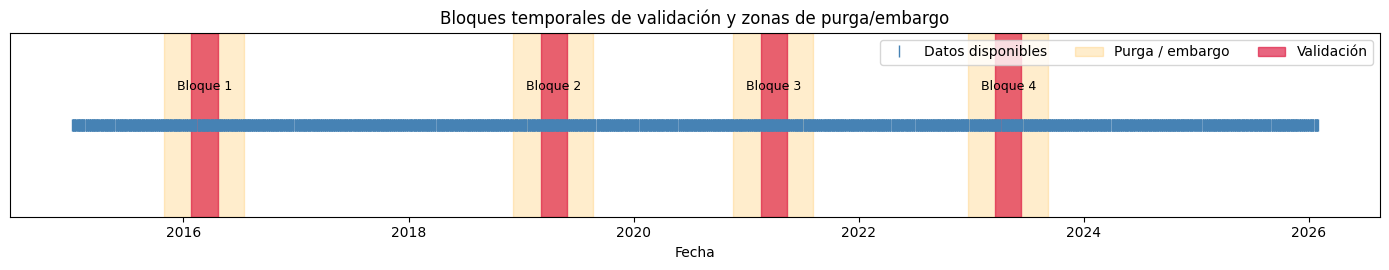

Figura guardada en: ..\reports\figures\autoregressive\validation_blocks.png


In [33]:
validation_blocks = select_validation_blocks(
    dates=components.index, n_blocks=VALIDATION_BLOCKS,
    block_length=VALIDATION_BLOCK_LENGTH, purge_size=PURGE_SIZE, seed=SEED,
)
validation_mask = np.zeros(len(components), dtype=bool)
for start, end in validation_blocks:
    validation_mask[start:end + 1] = True

validation_periods = pd.DataFrame(validation_blocks, columns=['start', 'end']).assign(
    start_date=lambda x: components.index[x['start']],
    end_date=lambda x: components.index[x['end']],
)
display(validation_periods)

fig, ax = plt.subplots(figsize=(14, 2.8))
ax.plot(
    components.index, np.zeros(len(components)), '|',
    color='steelblue', markersize=8, label='Datos disponibles',
)
for block_number, (start, end) in enumerate(validation_blocks):
    purge_start = max(0, start - PURGE_SIZE)
    purge_end = min(len(components) - 1, end + PURGE_SIZE)
    ax.axvspan(
        components.index[purge_start], components.index[purge_end],
        color='orange', alpha=0.20,
        label='Purga / embargo' if block_number == 0 else None,
    )
    ax.axvspan(
        components.index[start], components.index[end],
        color='crimson', alpha=0.65,
        label='Validación' if block_number == 0 else None,
    )
    ax.text(
        components.index[start + (end - start) // 2], 0.12,
        f'Bloque {block_number + 1}', ha='center', va='bottom', fontsize=9,
    )
ax.set_ylim(-0.35, 0.35)
ax.set_yticks([])
ax.set_xlabel('Fecha')
ax.set_title('Bloques temporales de validación y zonas de purga/embargo')
ax.legend(loc='upper right', ncol=3)
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'validation_blocks.png', dpi=160, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f'Figura guardada en: {FIGURE_DIR / "validation_blocks.png"}')


## 4. GRU probabilística y función objetivo

La red devuelve 61 medias y 61 log-varianzas. La Gaussian NLL se calcula de forma estable. Para que los 30 residuos no dominen por número de columnas, la métrica oficial es:

$$L_{selection}=0.20\,NLL_{market}+0.50\,NLL_{sector}+0.30\,NLL_{idio}.$$

Esta pérdida ponderada gobierna entrenamiento, early stopping, mejor época y ranking. La `total_nll` sin ponderar se conserva como diagnóstico; también se registran MSE por bloque y coberturas nominales del 68% y 95%.


In [34]:
def build_model(candidate):
    architecture = ARCHITECTURES[candidate['architecture']]
    return ProbabilisticGRU(
        input_dim=components.shape[1],
        hidden_dims=architecture['hidden_dims'], dropout=architecture['dropout'],
    )

def prepare_data(context_length):
    targets = autoregressive_target_indices(len(components), context_length)
    train_idx, val_idx = split_autoregressive_targets(
        targets, validation_blocks, context_length, purge_size=PURGE_SIZE
    )
    scaler = StandardScaler().fit(components.loc[~validation_mask].to_numpy())
    normalized = pd.DataFrame(
        scaler.transform(components.to_numpy()), index=components.index, columns=feature_names
    )
    train_x, train_y = make_autoregressive_samples(normalized, context_length, train_idx)
    val_x, val_y = make_autoregressive_samples(normalized, context_length, val_idx)
    return scaler, normalized, train_idx, val_idx, train_x, train_y, val_x, val_y


## 5. Grid de contextos y arquitecturas

Se prueban los candidatos: 4 longitudes de contexto por 4 arquitecturas. El learning rate permanece fijo para limitar el coste y mantener interpretable la comparación.


In [35]:
CANDIDATES = [
    {'architecture': architecture, 'context_length': context_length, 'learning_rate': LEARNING_RATE}
    for architecture in ARCHITECTURES for context_length in CONTEXT_LENGTHS
]
pd.DataFrame(CANDIDATES)


,architecture,context_length,learning_rate
0,gru_64,10,0.0005
1,gru_64,20,0.0005
2,gru_64,40,0.0005
3,gru_64,60,0.0005
4,gru_128,10,0.0005
5,gru_128,20,0.0005
6,gru_128,40,0.0005
7,gru_128,60,0.0005
8,gru_128_128,10,0.0005
9,gru_128_128,20,0.0005


## 6. Entrenamiento, early stopping y checkpoints

Cada candidato se inicializa desde cero. Se guardan checkpoint, scaler, historial y métricas de calibración de su mejor época.


In [25]:
candidate_results, candidate_histories, candidate_scalers = [], {}, {}
for candidate_id, candidate in enumerate(CANDIDATES):
    set_seed(SEED + candidate_id)
    scaler, normalized, train_idx, val_idx, train_x, train_y, val_x, val_y = prepare_data(candidate['context_length'])
    model = build_model(candidate)
    checkpoint = MODEL_DIR / 'candidates' / f'candidate_{candidate_id:03d}.pt'
    history_path = MODEL_DIR / 'histories' / f'candidate_{candidate_id:03d}.csv'
    scaler_path = MODEL_DIR / 'candidates' / f'candidate_{candidate_id:03d}_scaler.joblib'
    started = time.perf_counter()
    history, best_epoch, best_score = train_probabilistic_gru(
        model, train_x, train_y, val_x, val_y, epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE, learning_rate=LEARNING_RATE, patience=PATIENCE,
        seed=SEED + candidate_id, device=DEVICE, checkpoint_path=checkpoint,
        loss_weights=LOSS_WEIGHTS,
    )
    history_df = pd.DataFrame(history)
    history_df.to_csv(history_path, index=False); joblib.dump(scaler, scaler_path)
    candidate_histories[candidate_id] = history_df; candidate_scalers[candidate_id] = scaler
    best = history_df.iloc[best_epoch - 1]
    candidate_results.append({
        'candidate_id': candidate_id, **candidate, **ARCHITECTURES[candidate['architecture']],
        'market_weight': LOSS_WEIGHTS['market'], 'sector_weight': LOSS_WEIGHTS['sector'],
        'idio_weight': LOSS_WEIGHTS['idio'],
        'best_epoch': best_epoch, 'val_selection_score': best_score,
        'val_total_nll': best['val_total_nll'], 'val_mse': best['val_mse'],
        'val_market_mse': best['val_market_mse'], 'val_sector_mse': best['val_sector_mse'],
        'val_idio_mse': best['val_idio_mse'], 'val_coverage_68': best['val_coverage_68'],
        'val_coverage_95': best['val_coverage_95'],
        'val_standardized_residual_mean': best['val_standardized_residual_mean'],
        'val_standardized_residual_std': best['val_standardized_residual_std'],
        'n_parameters': sum(p.numel() for p in model.parameters()),
        'training_seconds': time.perf_counter() - started,
        'n_train': len(train_x), 'n_validation': len(val_x),
        'checkpoint': str(checkpoint), 'scaler_path': str(scaler_path), 'history_path': str(history_path),
    })

results_df = pd.DataFrame(candidate_results).sort_values('val_selection_score').reset_index(drop=True)
results_df.to_csv(MODEL_DIR / 'candidate_results.csv', index=False)
results_df


,candidate_id,architecture,context_length,learning_rate,hidden_dims,dropout,market_weight,sector_weight,idio_weight,best_epoch,...,val_coverage_95,val_standardized_residual_mean,val_standardized_residual_std,n_parameters,training_seconds,n_train,n_validation,checkpoint,scaler_path,history_path
0,12,gru_256_128,10,0.0005,"[256, 128]",0.2,0.2,0.5,0.3,3,...,0.942896,-0.000361,1.008693,408954,79.807355,2023,240,..\models\autoregressive\candidates\candidate_...,..\models\autoregressive\candidates\candidate_...,..\models\autoregressive\histories\candidate_0...
1,11,gru_128_128,60,0.0005,"[128, 128]",0.1,0.2,0.5,0.3,3,...,0.948292,0.002003,0.980509,188154,286.251525,1773,240,..\models\autoregressive\candidates\candidate_...,..\models\autoregressive\candidates\candidate_...,..\models\autoregressive\histories\candidate_0...
2,4,gru_128,10,0.0005,[128],0.0,0.2,0.5,0.3,5,...,0.945014,-0.003605,0.993736,89082,7.773467,2023,240,..\models\autoregressive\candidates\candidate_...,..\models\autoregressive\candidates\candidate_...,..\models\autoregressive\histories\candidate_0...
3,9,gru_128_128,20,0.0005,"[128, 128]",0.1,0.2,0.5,0.3,3,...,0.943169,-0.001900,1.013311,188154,70.054912,1973,240,..\models\autoregressive\candidates\candidate_...,..\models\autoregressive\candidates\candidate_...,..\models\autoregressive\histories\candidate_0...
4,13,gru_256_128,20,0.0005,"[256, 128]",0.2,0.2,0.5,0.3,3,...,0.946858,-0.001655,0.993255,408954,149.405908,1973,240,..\models\autoregressive\candidates\candidate_...,..\models\autoregressive\candidates\candidate_...,..\models\autoregressive\histories\candidate_0...
5,8,gru_128_128,10,0.0005,"[128, 128]",0.1,0.2,0.5,0.3,3,...,0.945628,-0.000571,0.998347,188154,14.654382,2023,240,..\models\autoregressive\candidates\candidate_...,..\models\autoregressive\candidates\candidate_...,..\models\autoregressive\histories\candidate_0...
6,10,gru_128_128,40,0.0005,"[128, 128]",0.1,0.2,0.5,0.3,3,...,0.944262,0.003957,0.998233,188154,194.237768,1873,240,..\models\autoregressive\candidates\candidate_...,..\models\autoregressive\candidates\candidate_...,..\models\autoregressive\histories\candidate_0...
7,14,gru_256_128,40,0.0005,"[256, 128]",0.2,0.2,0.5,0.3,3,...,0.942418,-0.005240,1.015758,408954,295.269465,1873,240,..\models\autoregressive\candidates\candidate_...,..\models\autoregressive\candidates\candidate_...,..\models\autoregressive\histories\candidate_0...
8,7,gru_128,60,0.0005,[128],0.0,0.2,0.5,0.3,7,...,0.946926,-0.003282,0.993024,89082,55.227438,1773,240,..\models\autoregressive\candidates\candidate_...,..\models\autoregressive\candidates\candidate_...,..\models\autoregressive\histories\candidate_0...
9,6,gru_128,40,0.0005,[128],0.0,0.2,0.5,0.3,6,...,0.945150,-0.000374,1.007887,89082,45.088445,1873,240,..\models\autoregressive\candidates\candidate_...,..\models\autoregressive\candidates\candidate_...,..\models\autoregressive\histories\candidate_0...


## 7. Curvas completas de todos los candidatos

Para cada candidato se muestran y guardan simultáneamente:

- la NLL de cada familia de factores, separando `train` y `validation`;
- la pérdida total ponderada usada realmente para entrenar y seleccionar el modelo;
- la NLL total sin ponderar, conservada como diagnóstico;
- la contribución ponderada de mercado, sector e idiosincrático a la pérdida de validation.

Así puede comprobarse si una mejora de la loss total procede de todas las familias o está dominada por una sola.


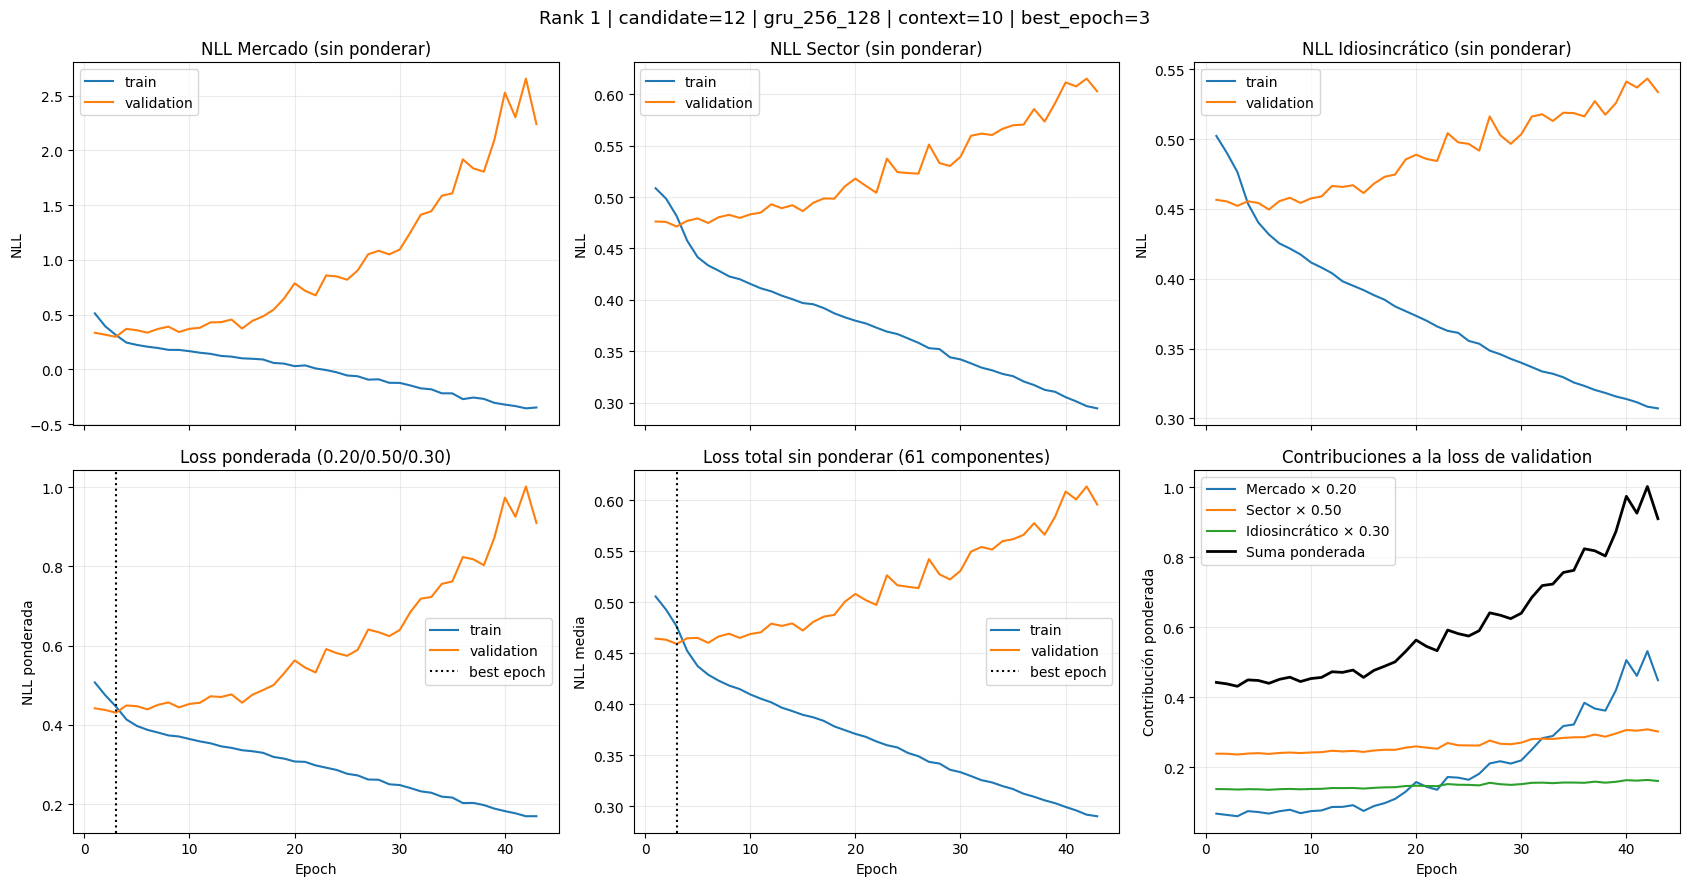

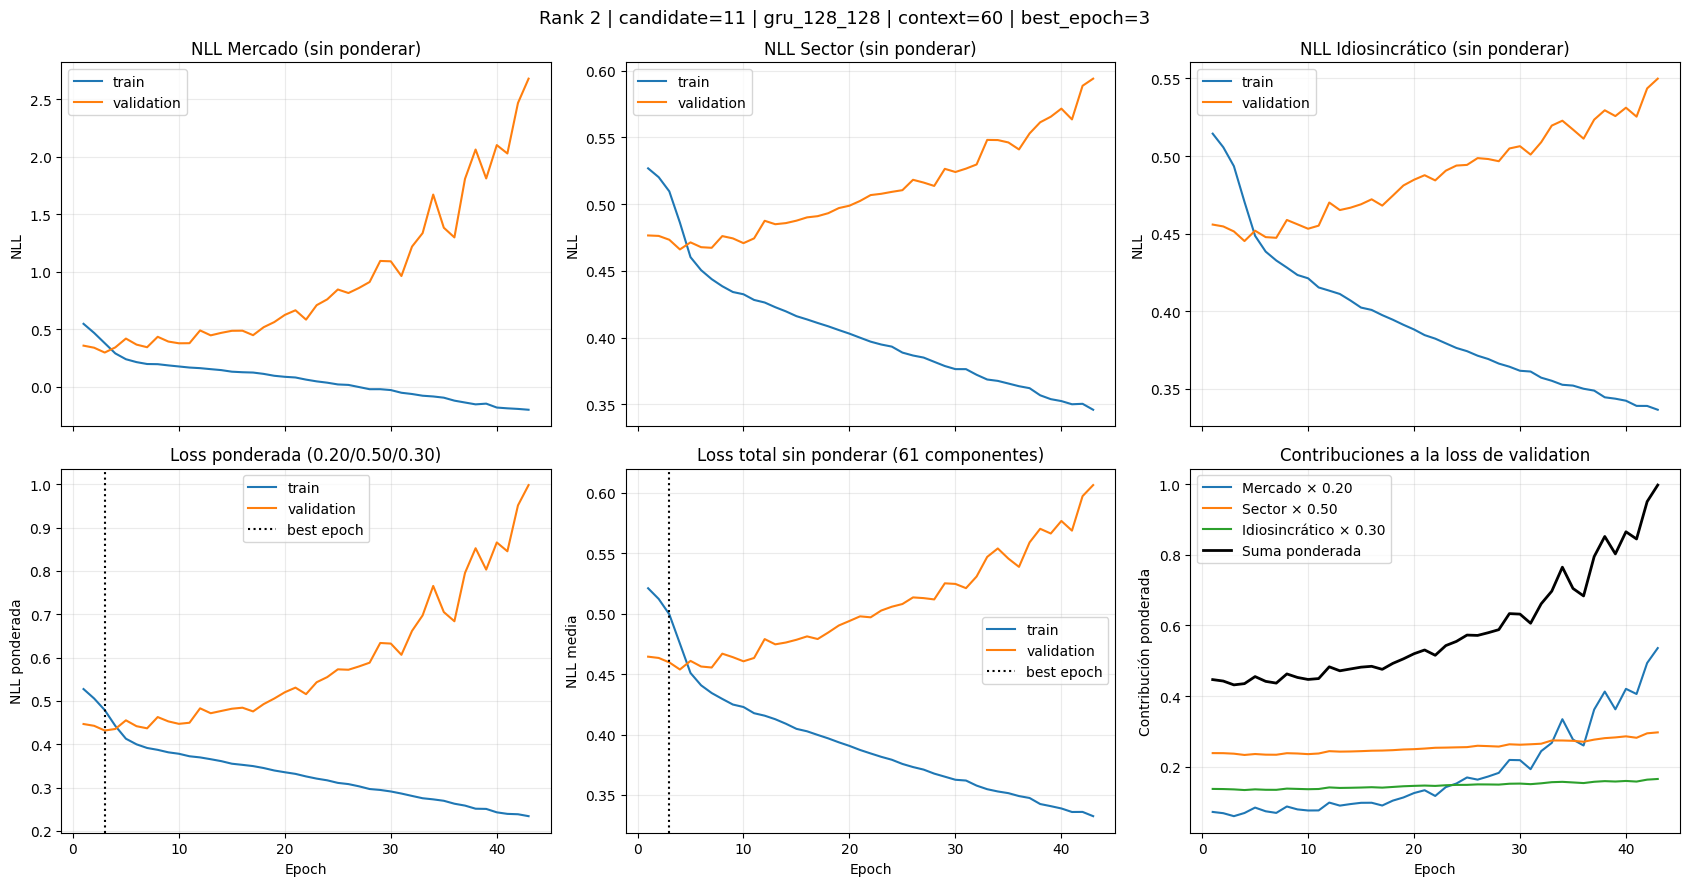

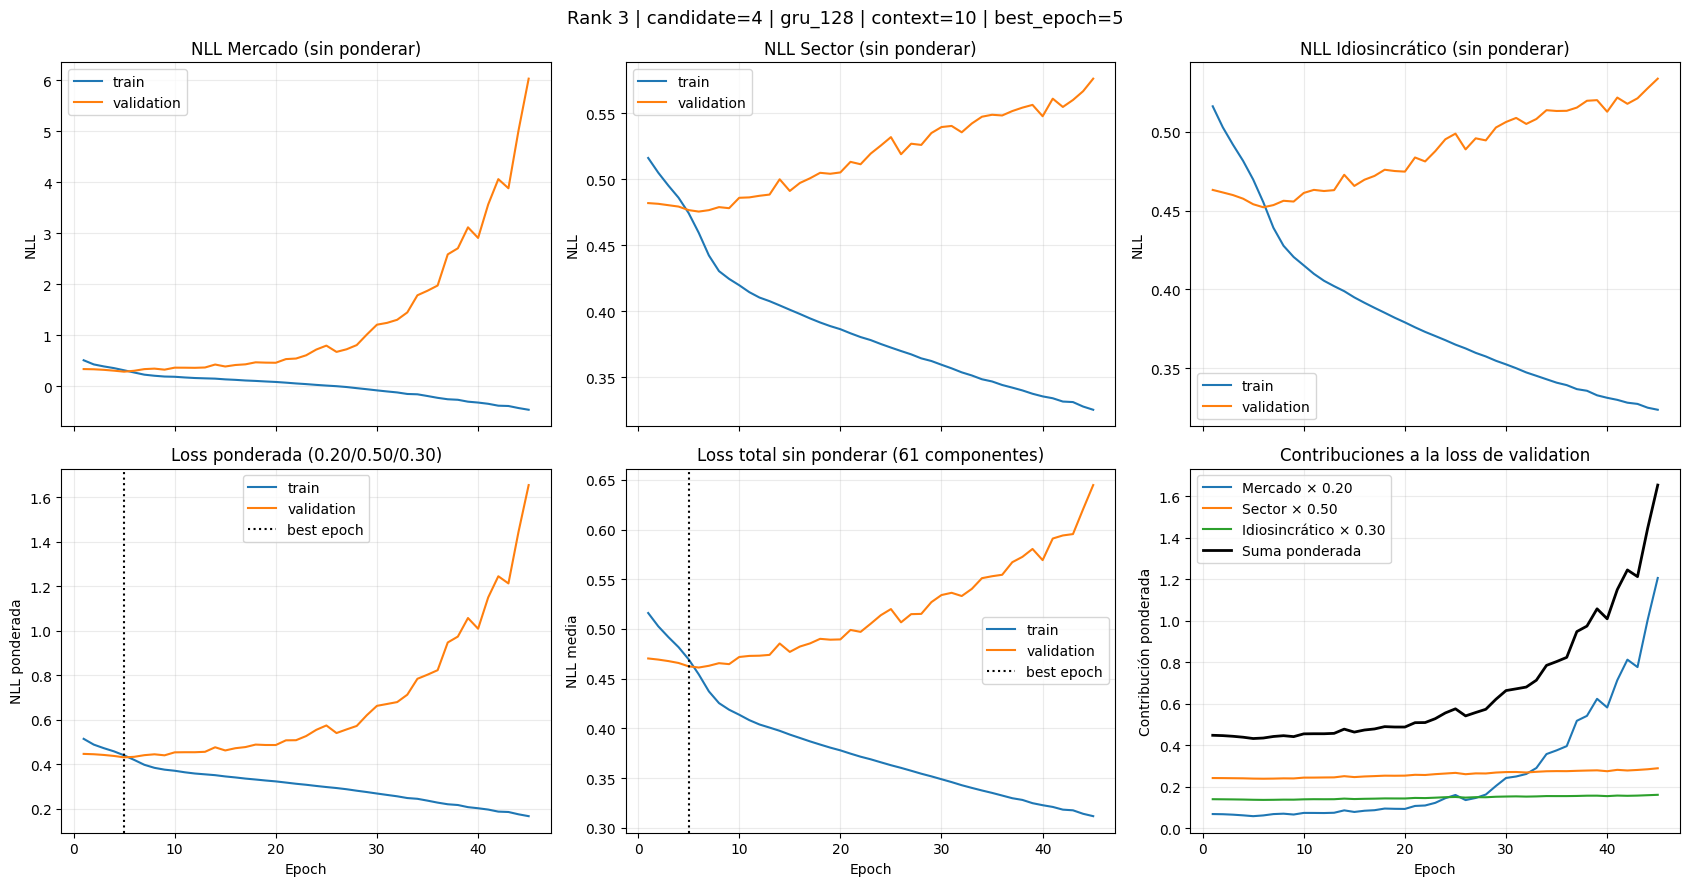

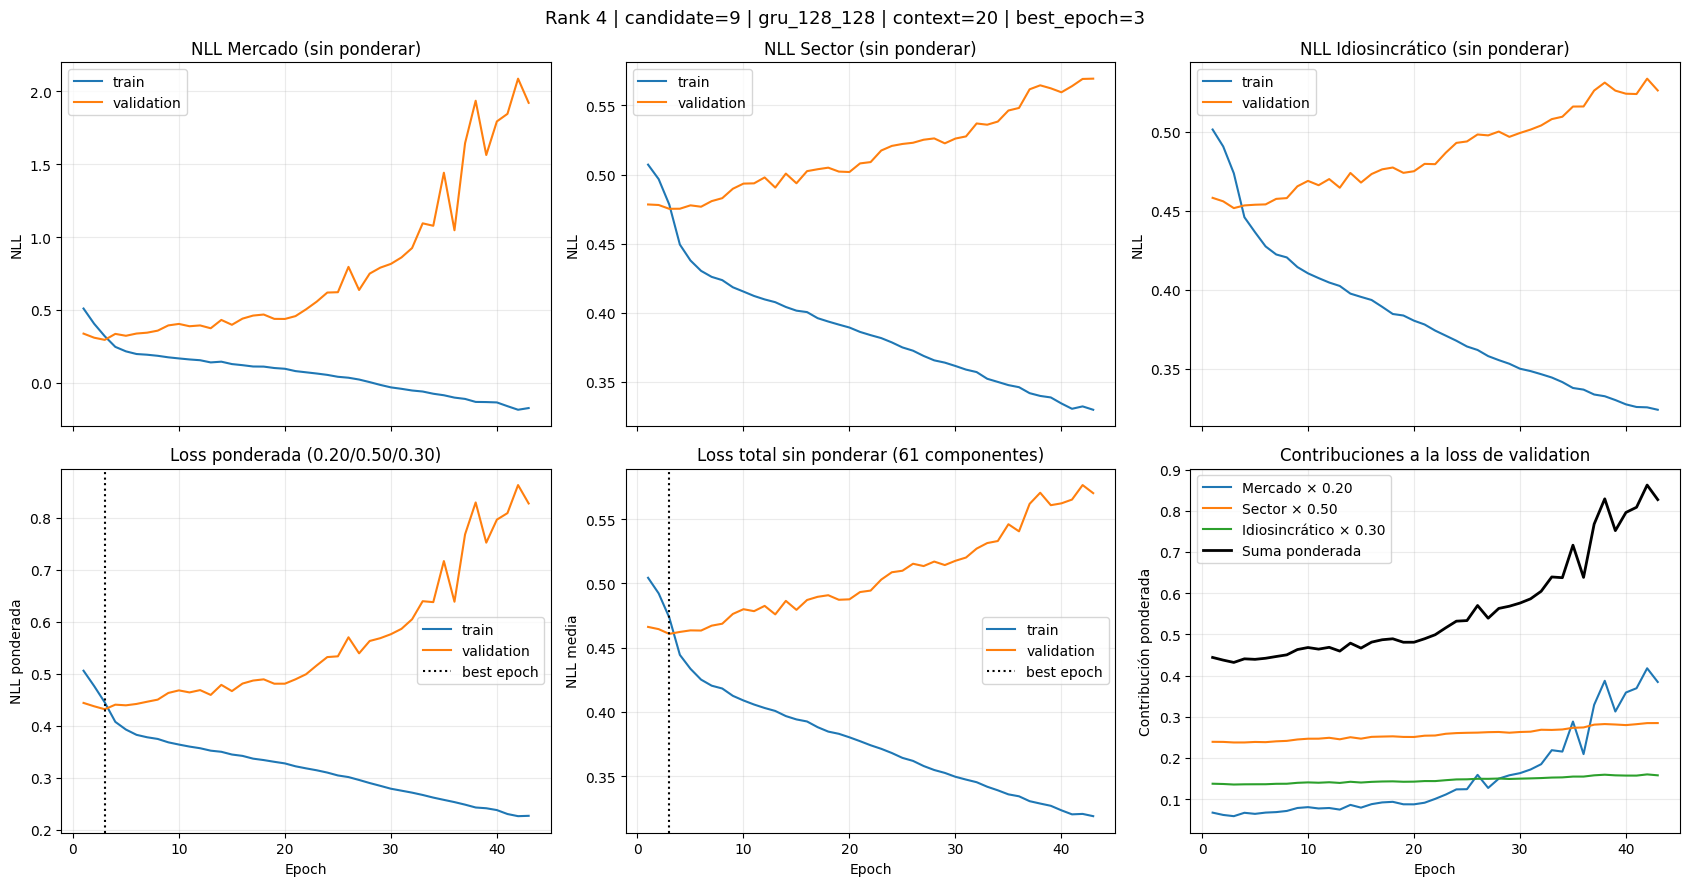

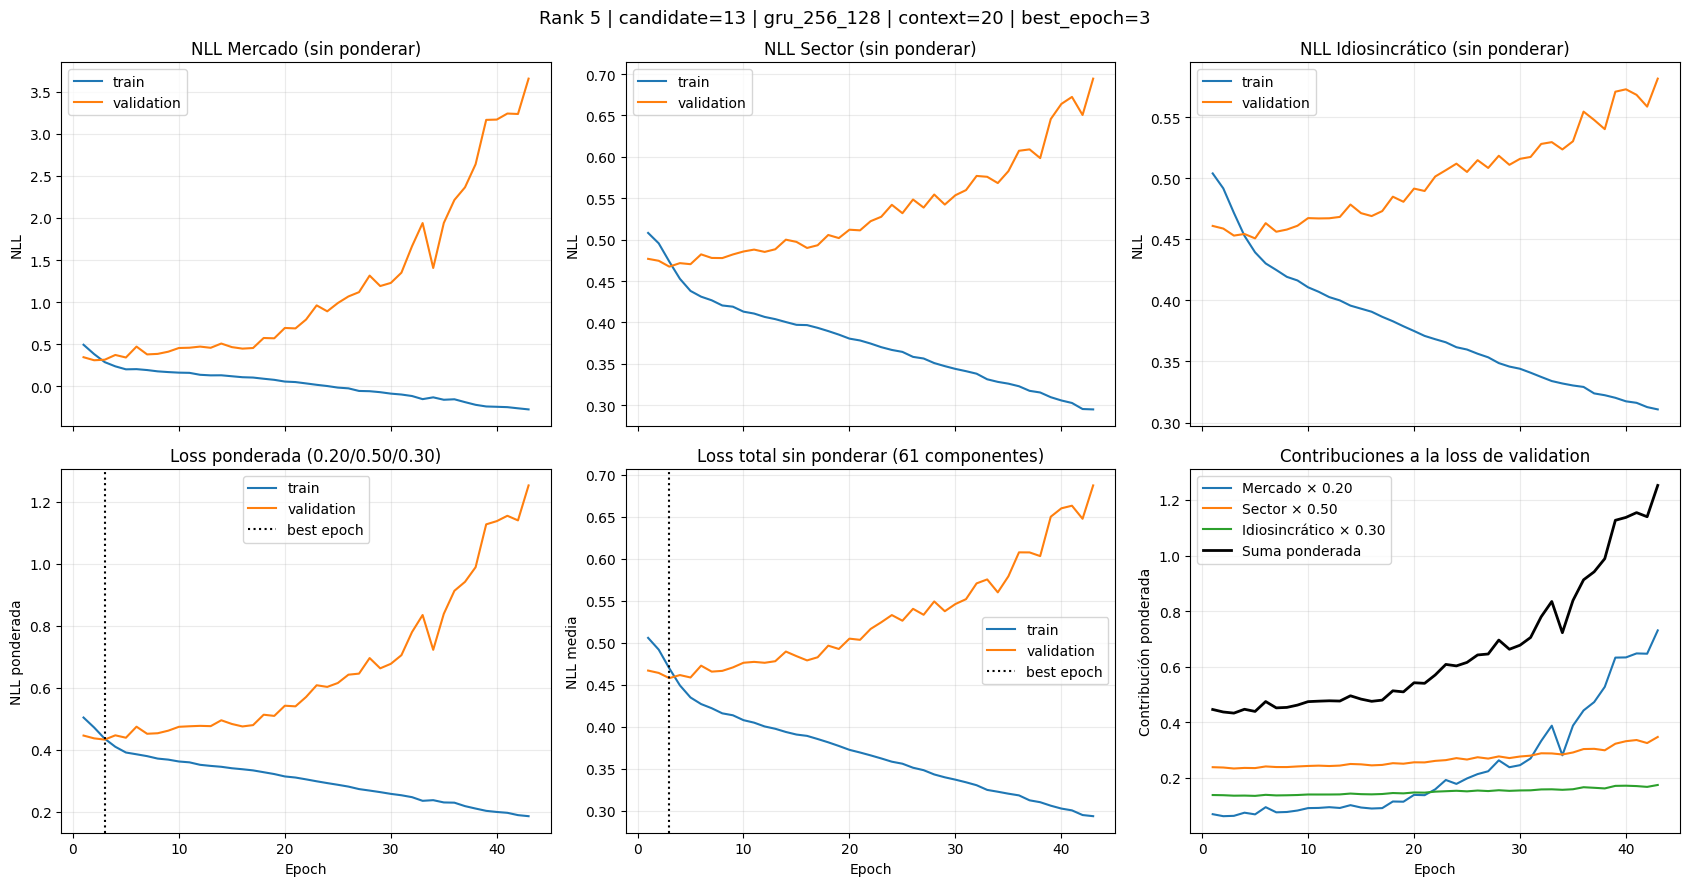

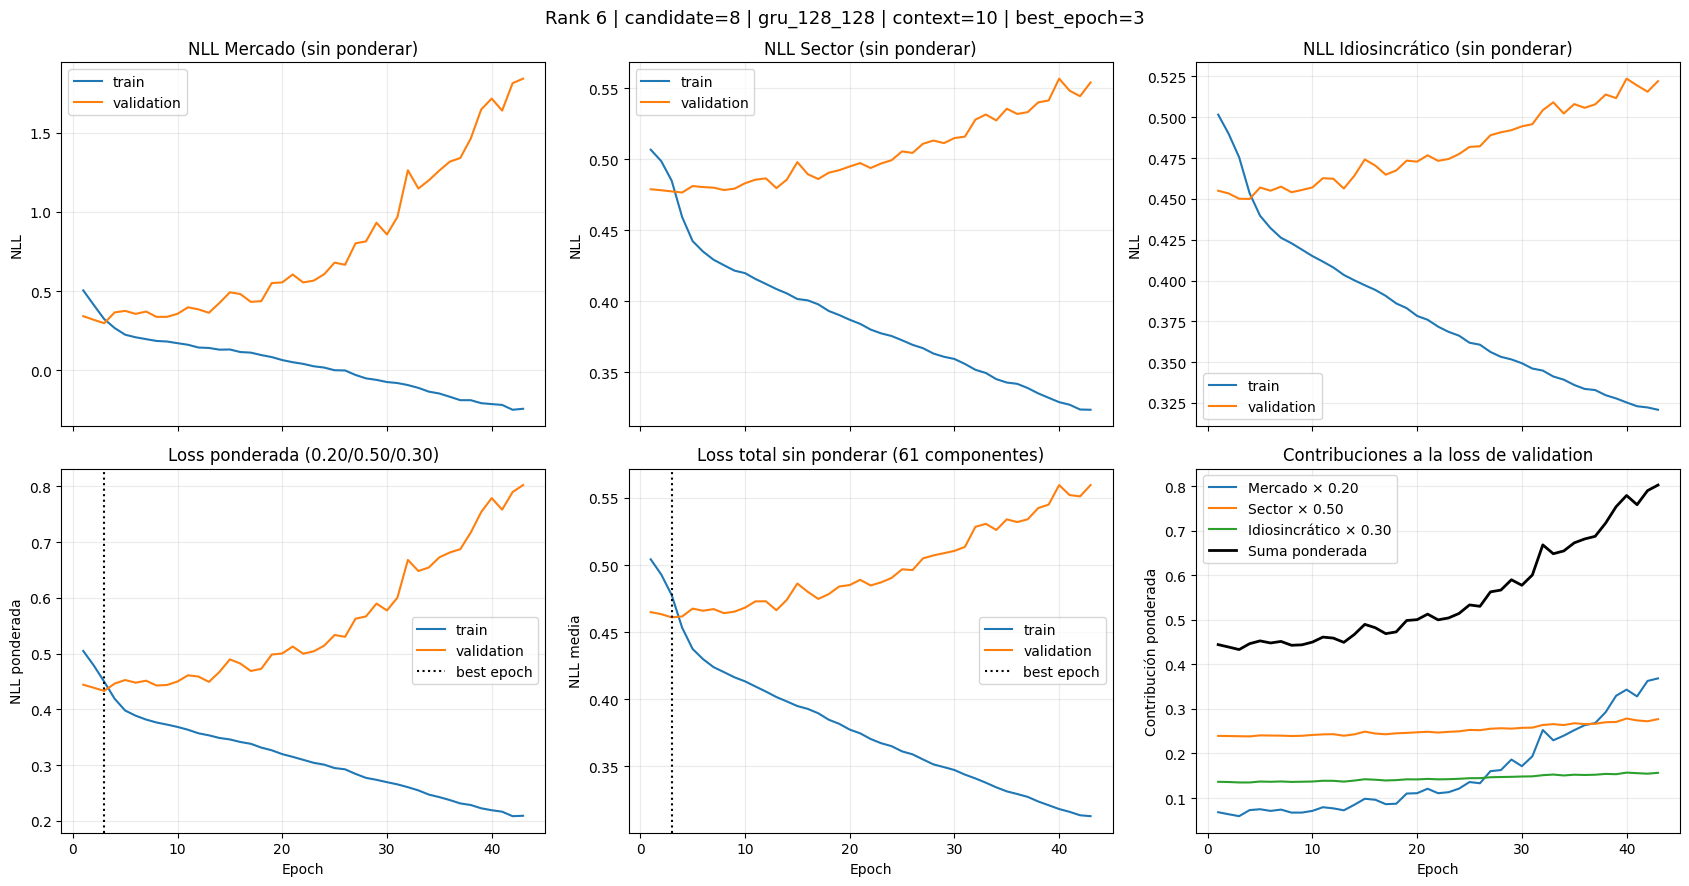

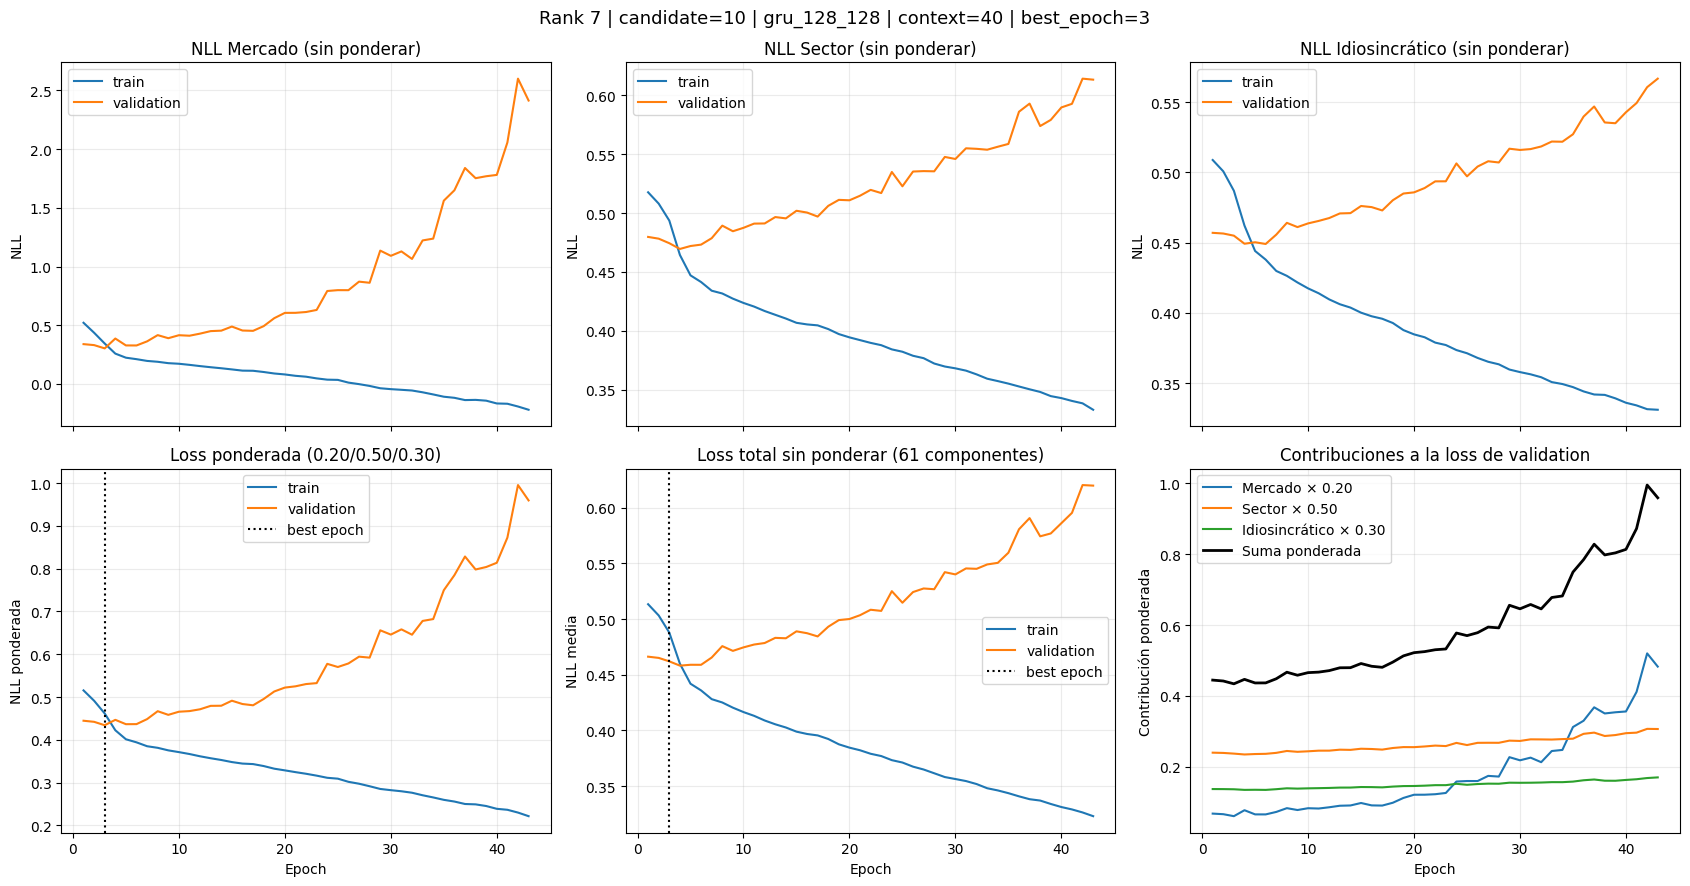

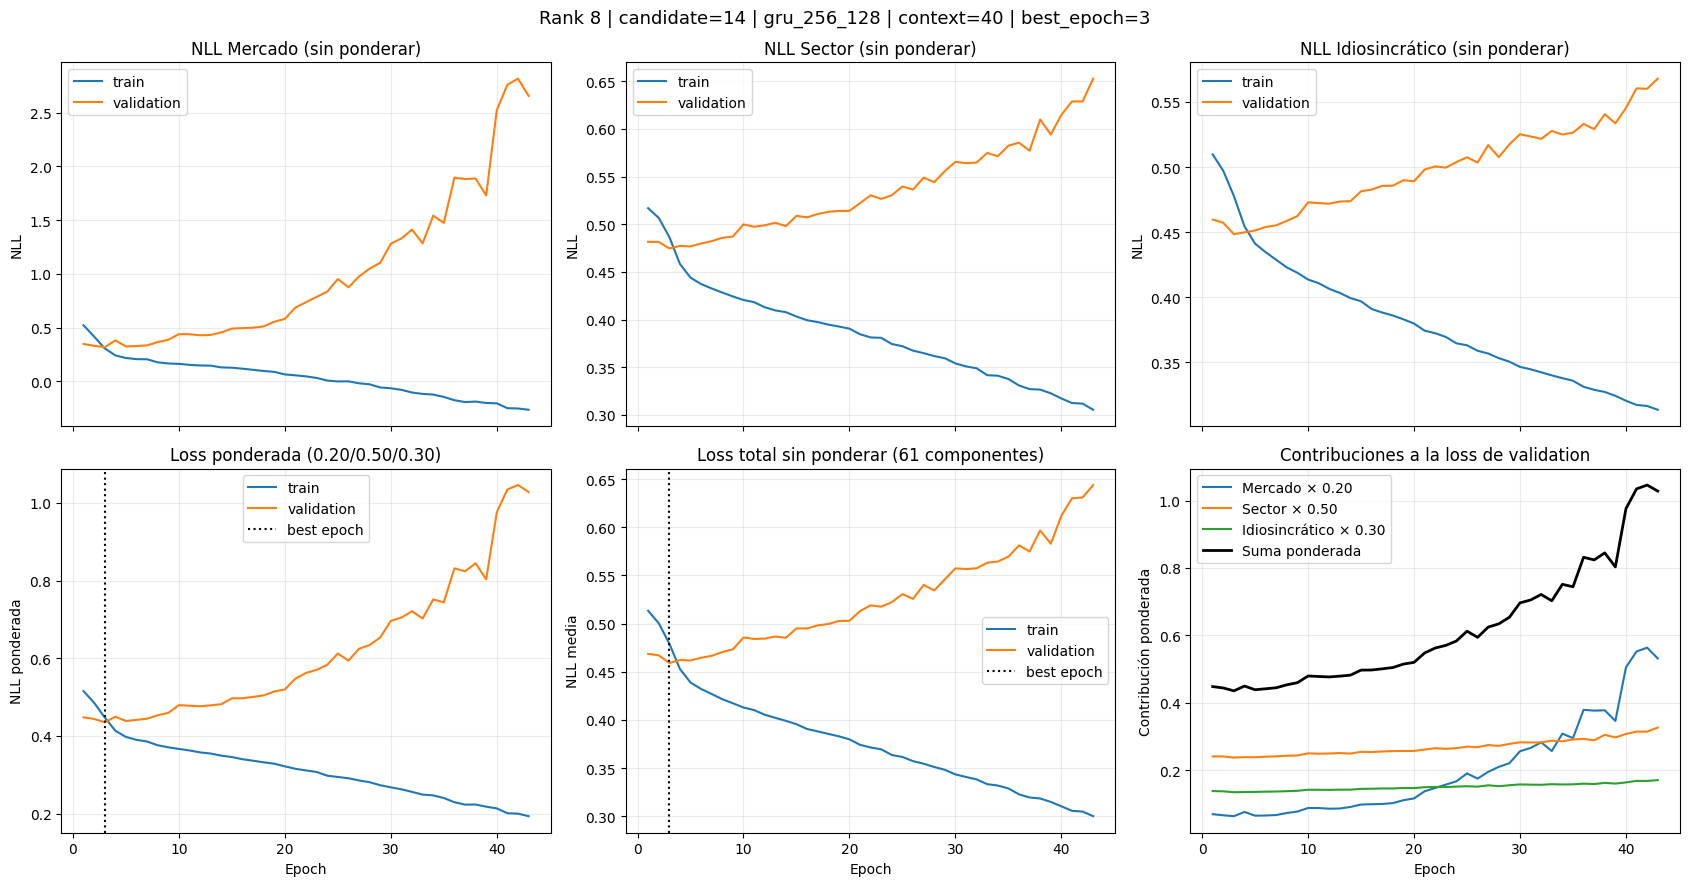

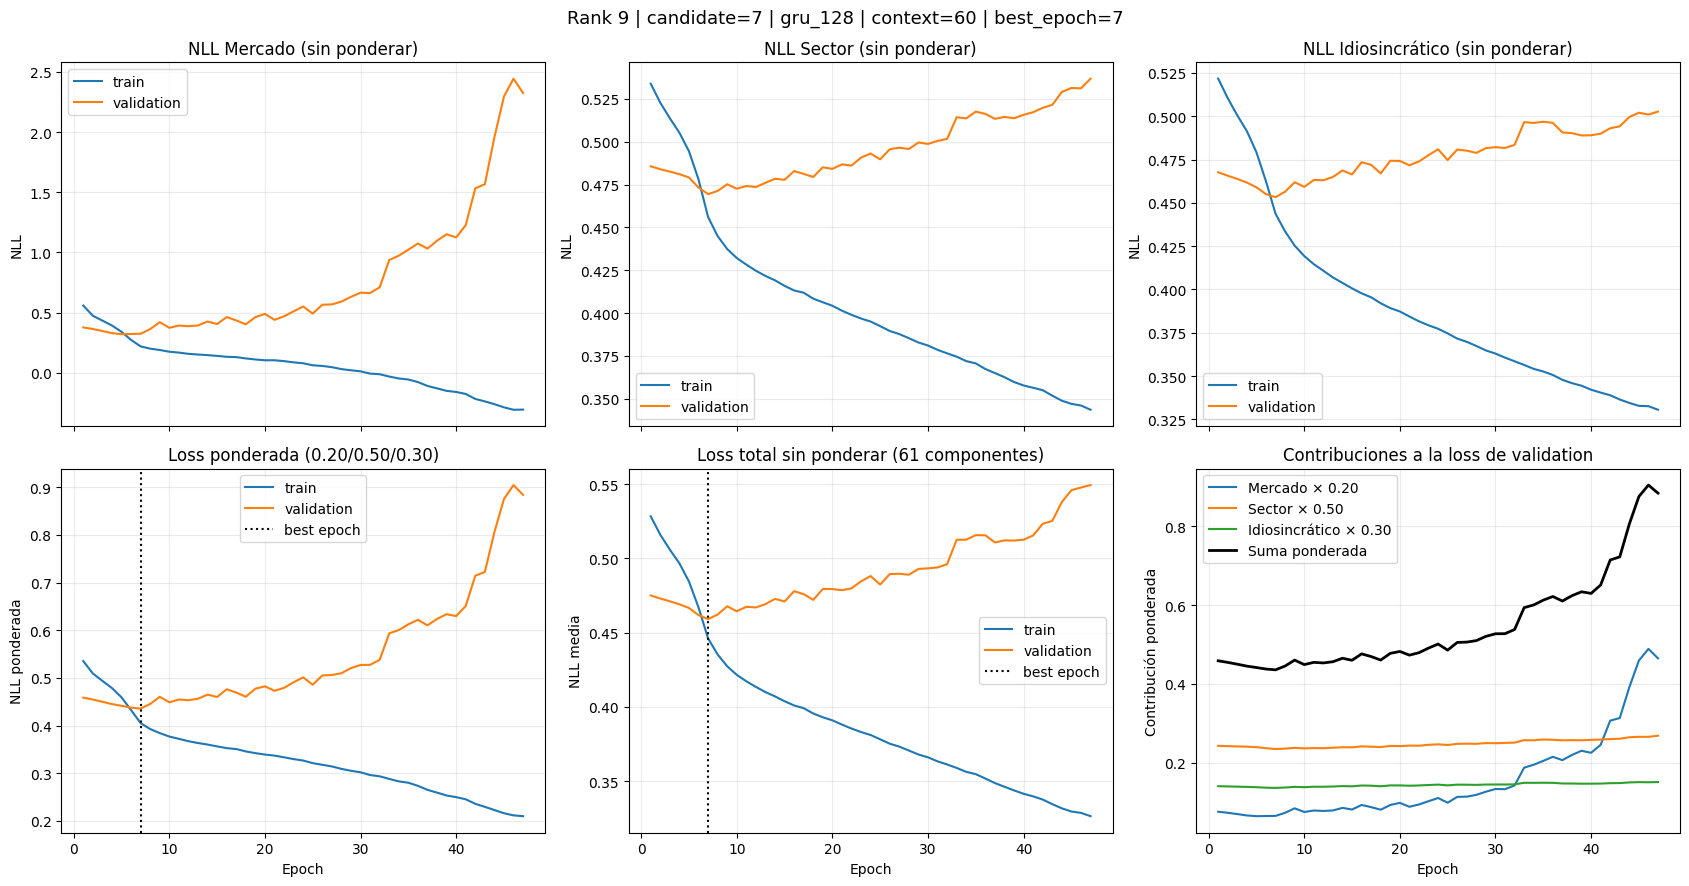

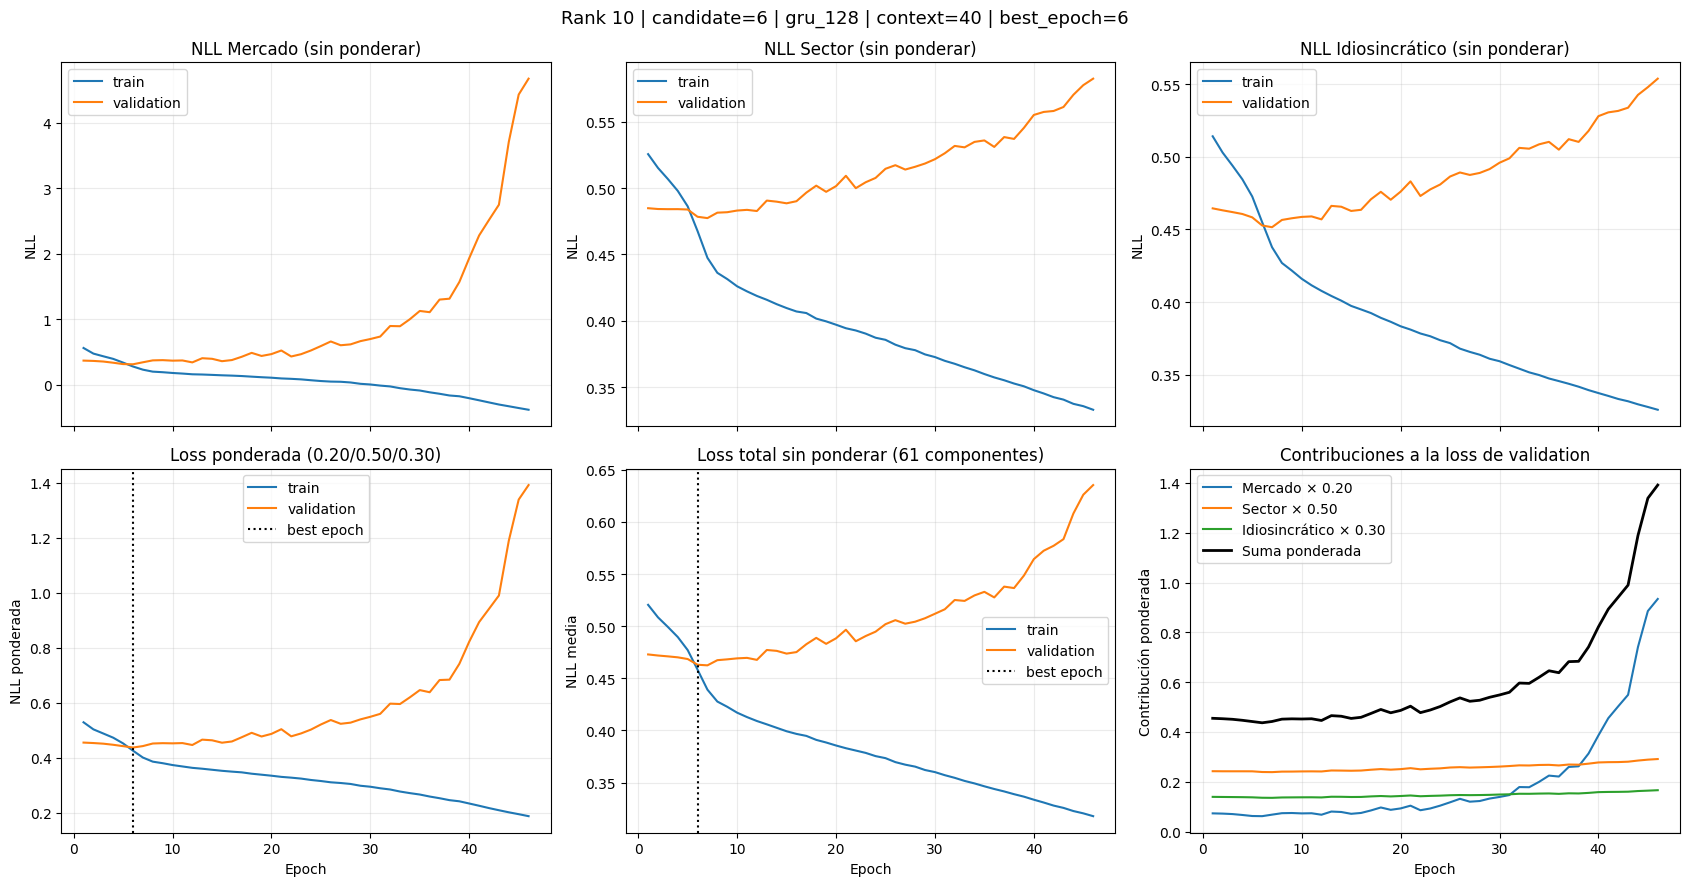

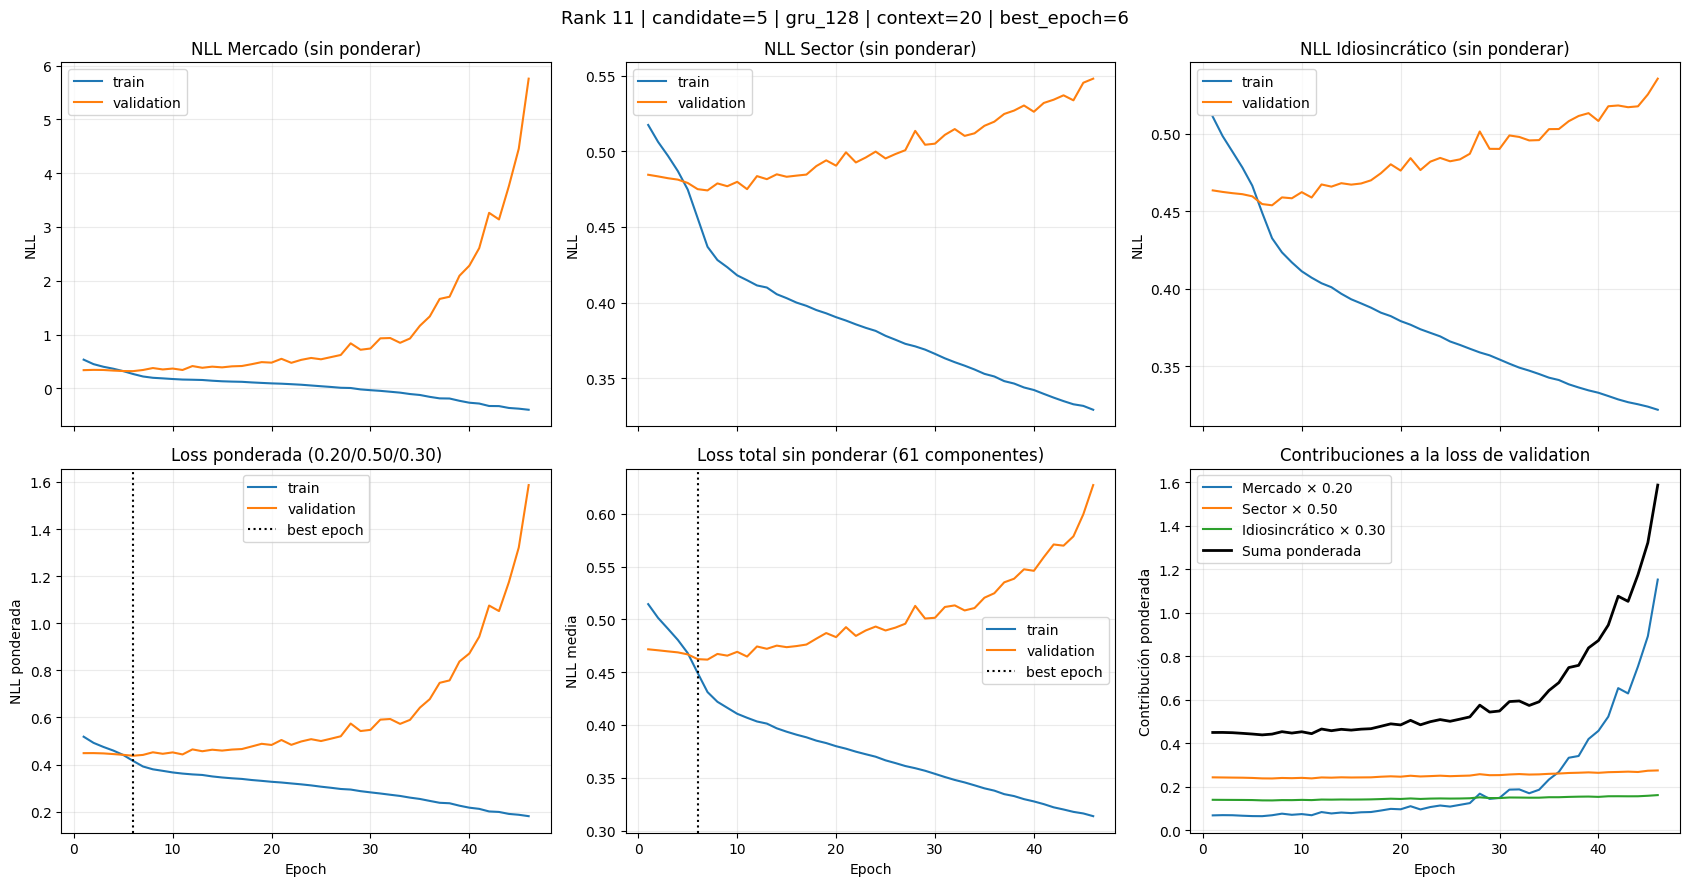

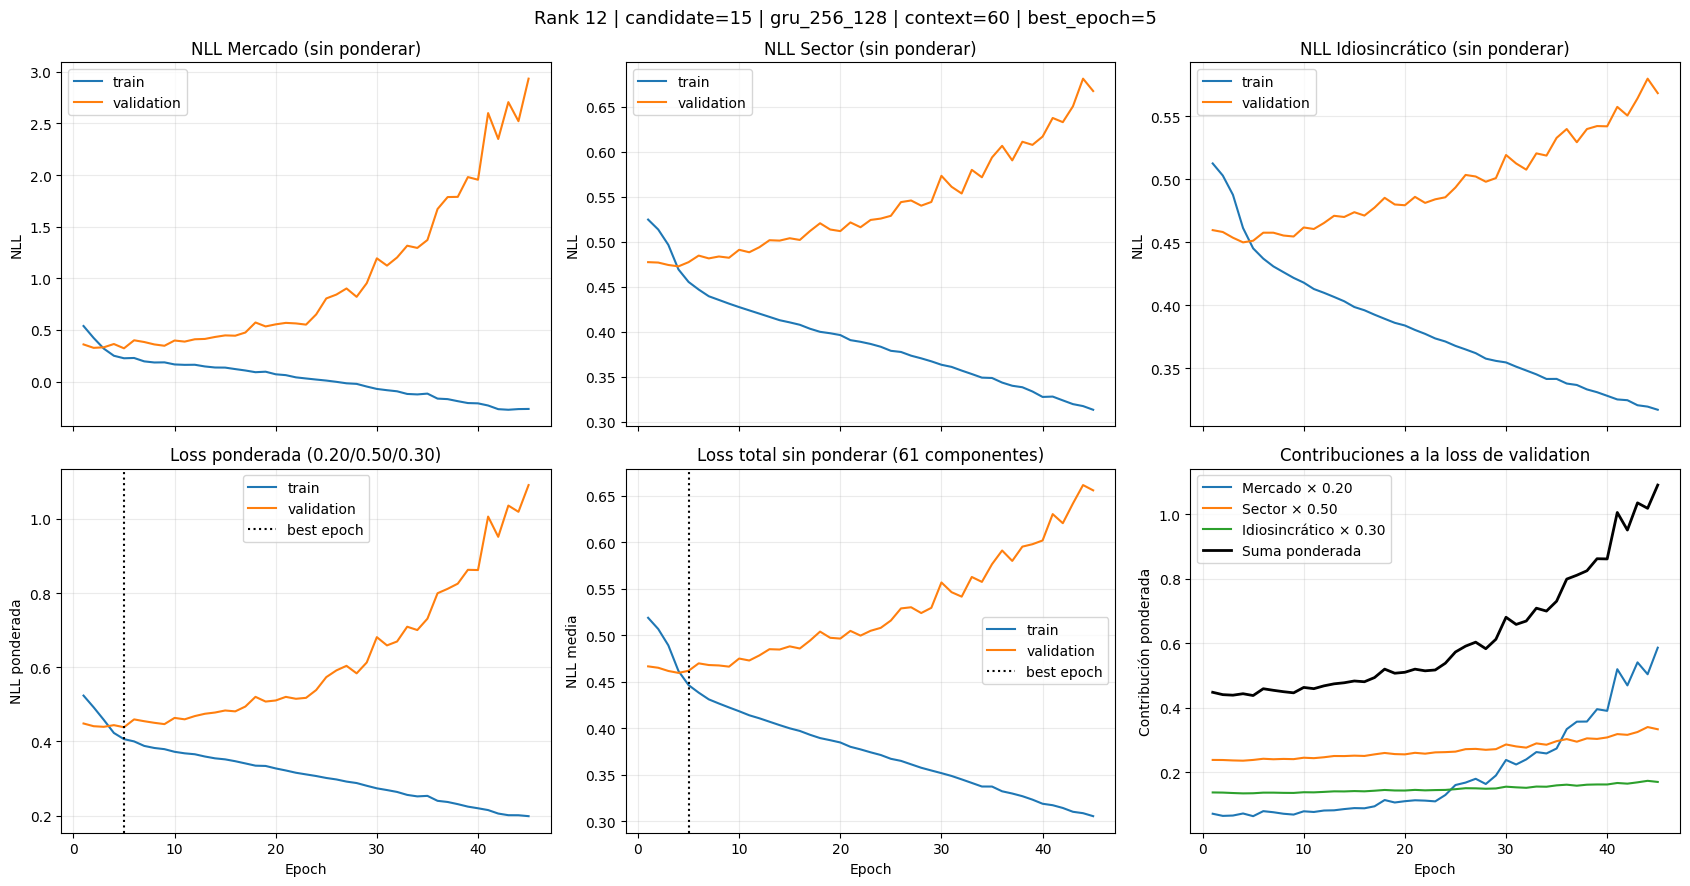

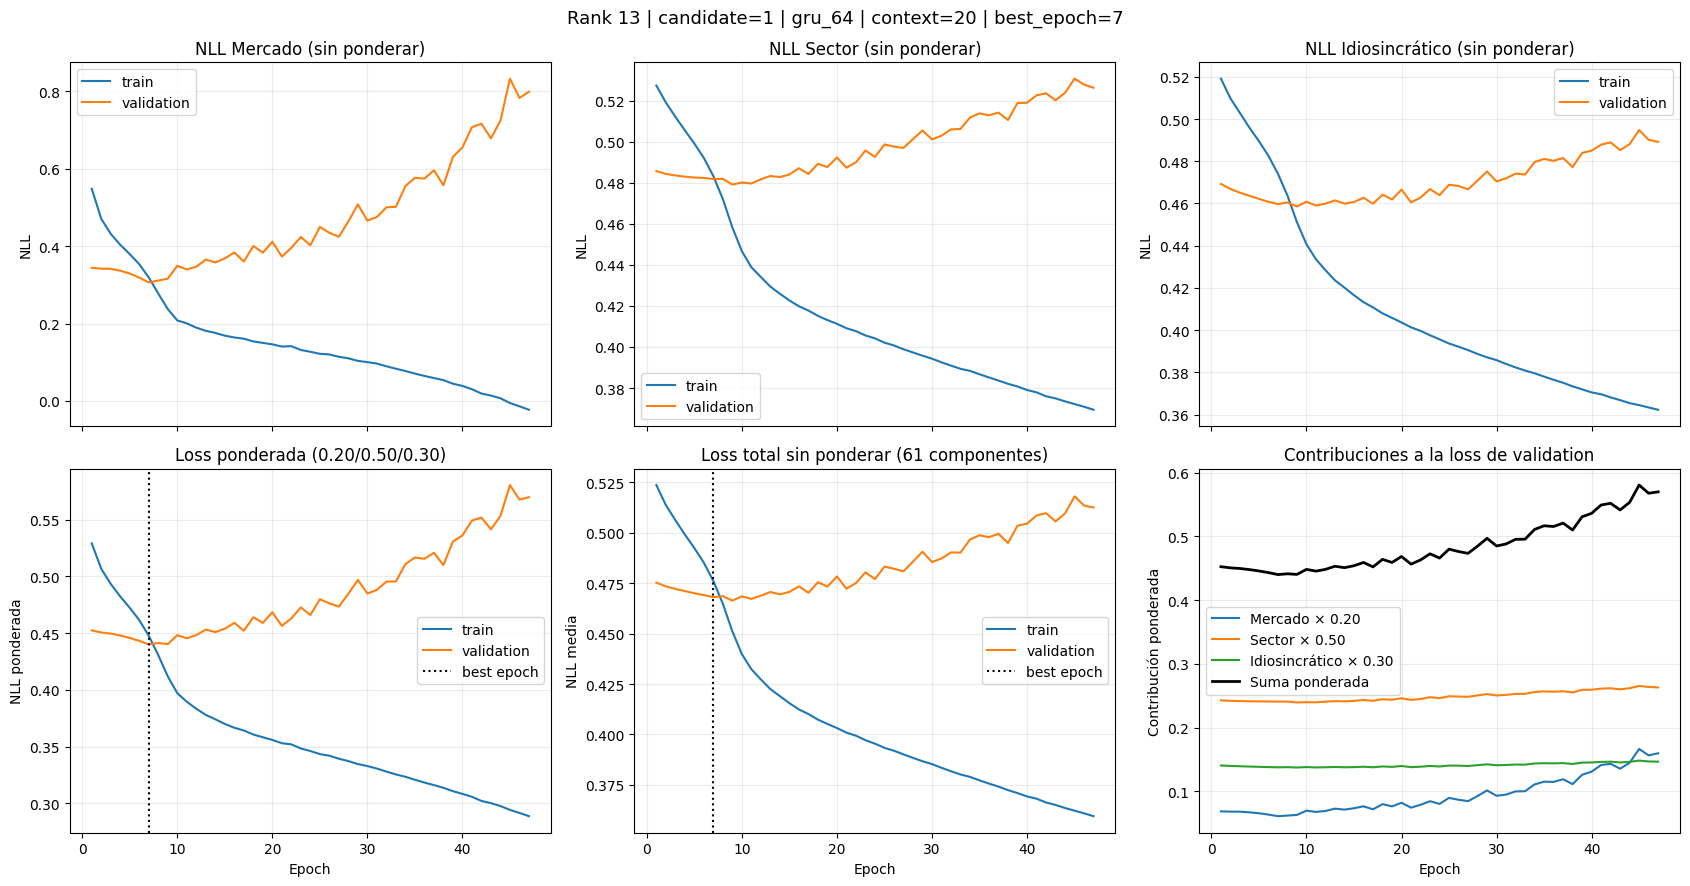

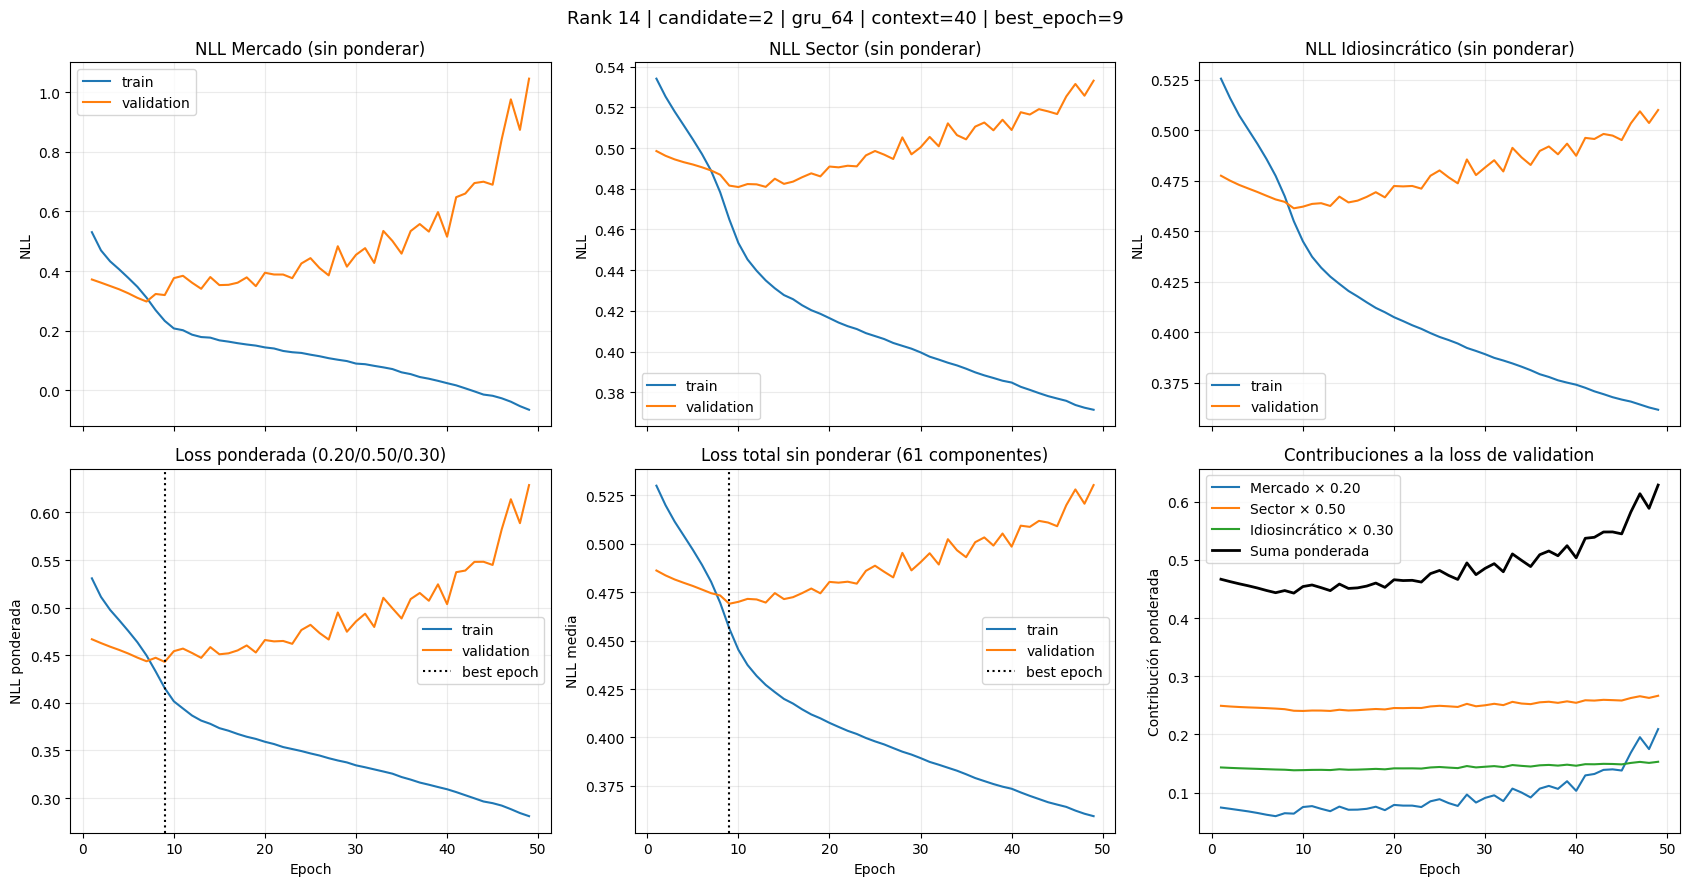

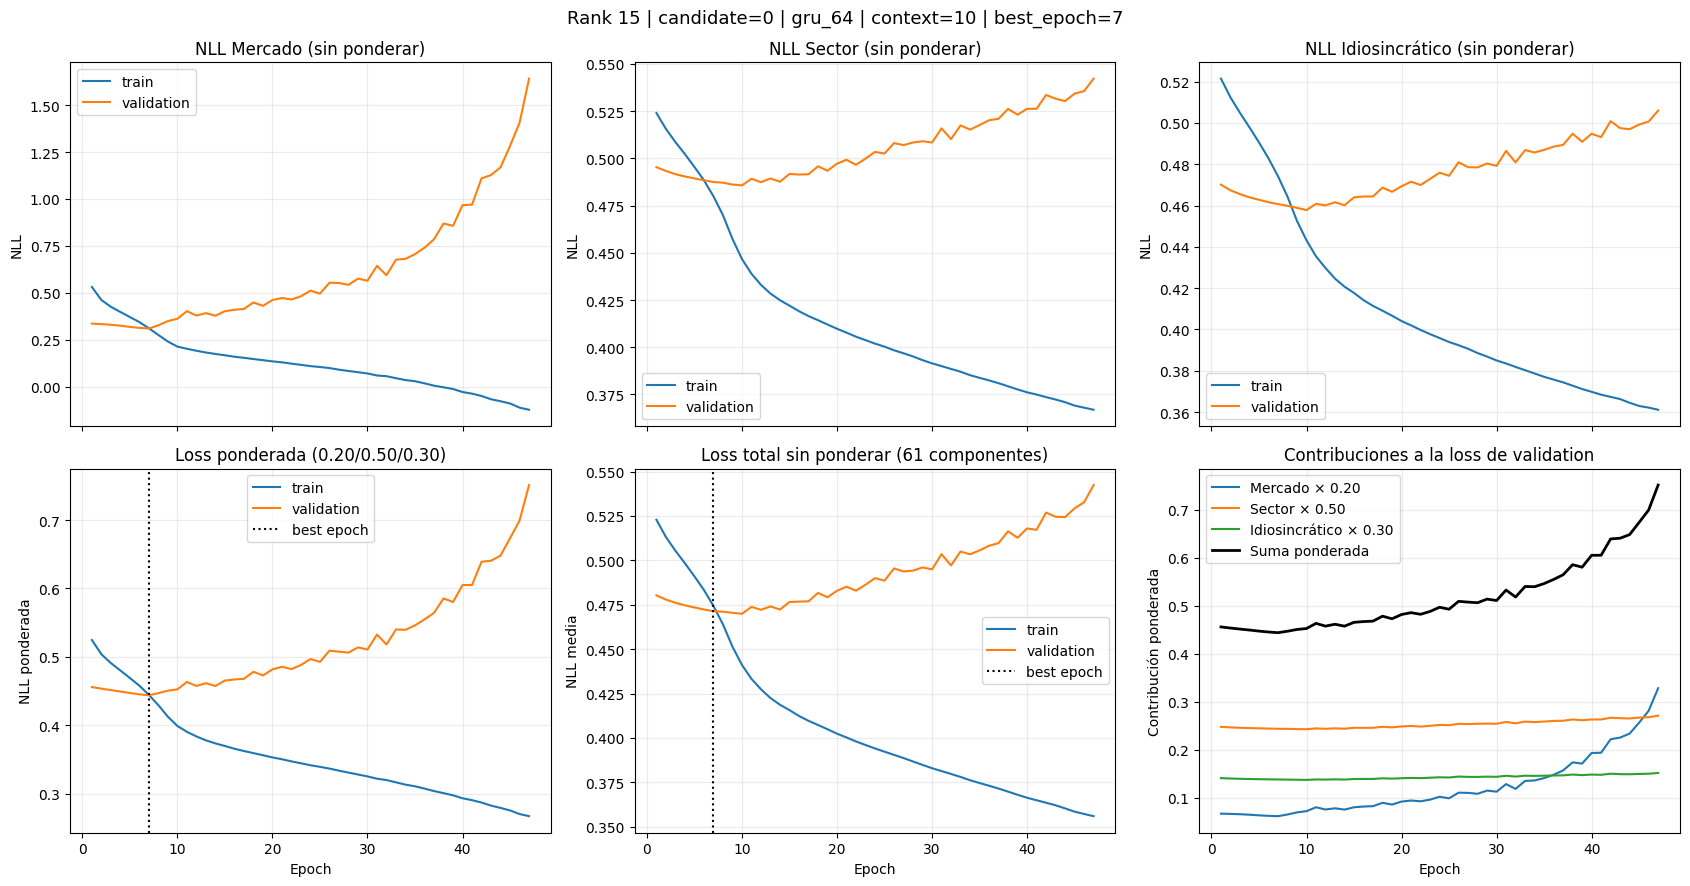

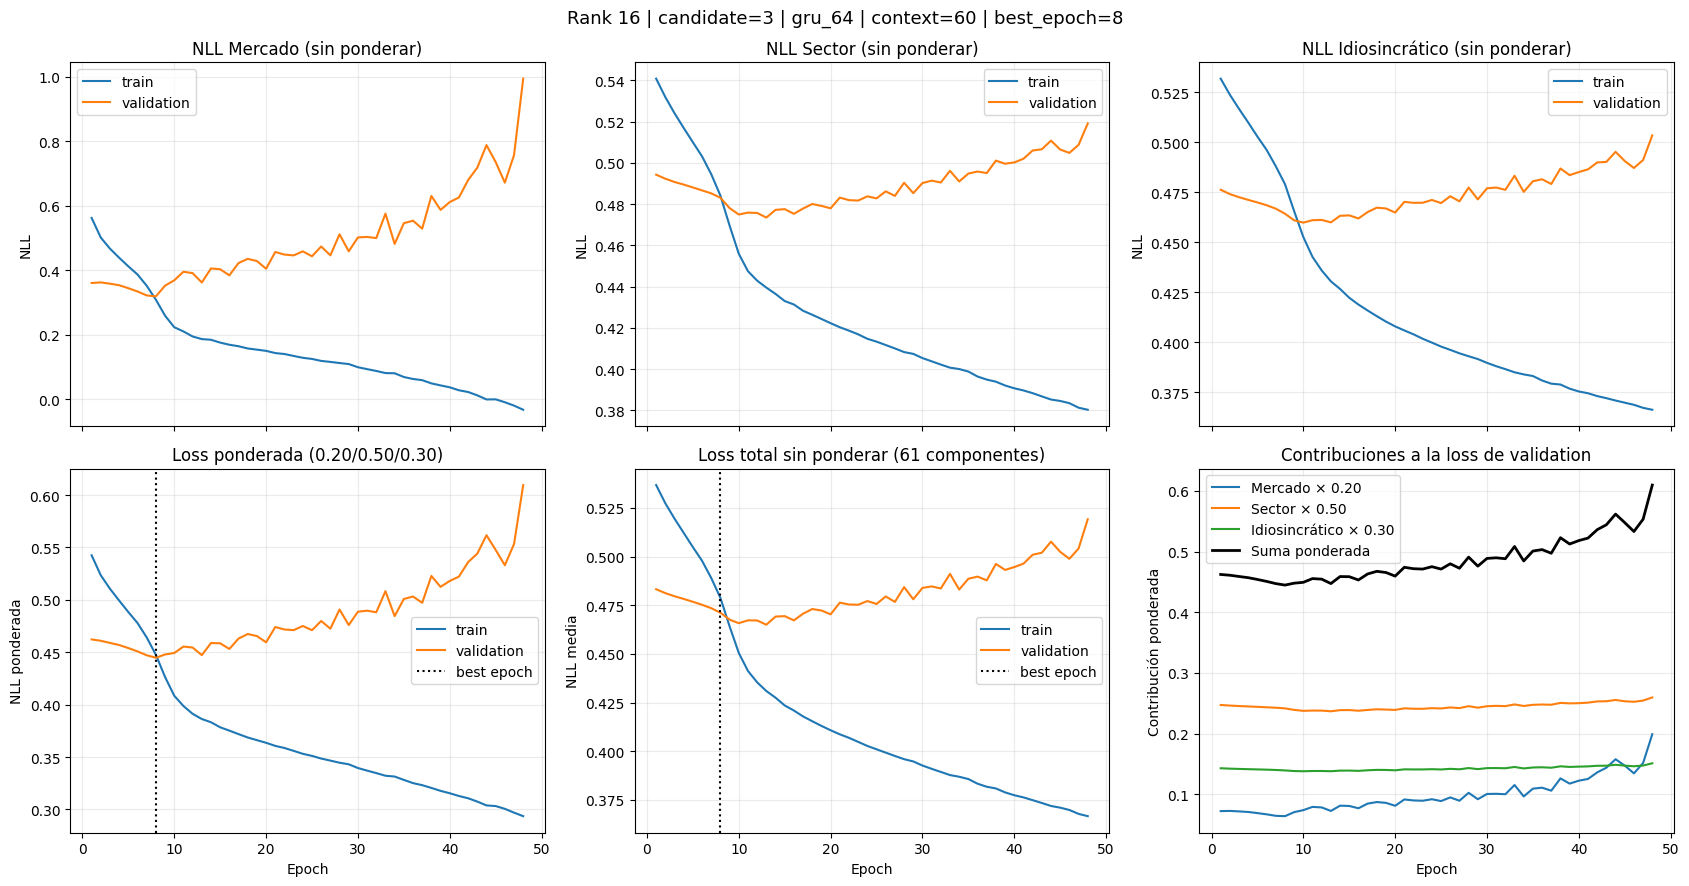

In [26]:
factor_labels = {
    'market': 'Mercado',
    'sector': 'Sector',
    'idio': 'Idiosincrático',
}

# Si el entrenamiento se hizo en otra sesión, recupera resultados e historiales de los CSV.
if 'results_df' not in globals():
    results_df = pd.read_csv(MODEL_DIR / 'candidate_results.csv').sort_values('val_selection_score').reset_index(drop=True)
if 'candidate_histories' not in globals():
    candidate_histories = {}

for rank, row in results_df.iterrows():
    candidate_id = int(row['candidate_id'])
    history = candidate_histories.get(candidate_id)
    if history is None:
        history = pd.read_csv(row['history_path'])
    fig, axes = plt.subplots(2, 3, figsize=(17, 9), sharex=True)

    # Fila superior: una gráfica independiente por familia de factores.
    for axis, factor in zip(axes[0], ('market', 'sector', 'idio')):
        axis.plot(history['epoch'], history[f'train_{factor}_nll'], label='train')
        axis.plot(history['epoch'], history[f'val_{factor}_nll'], label='validation')
        axis.set_title(f"NLL {factor_labels[factor]} (sin ponderar)")
        axis.set_ylabel('NLL')
        axis.grid(alpha=0.25)
        axis.legend()

    # Loss oficial: suma ponderada 0.20 market + 0.50 sector + 0.30 idio.
    axes[1, 0].plot(history['epoch'], history['train_selection_score'], label='train')
    axes[1, 0].plot(history['epoch'], history['val_selection_score'], label='validation')
    axes[1, 0].axvline(row['best_epoch'], color='black', linestyle=':', label='best epoch')
    axes[1, 0].set_title(
        'Loss ponderada '
        f"({LOSS_WEIGHTS['market']:.2f}/{LOSS_WEIGHTS['sector']:.2f}/{LOSS_WEIGHTS['idio']:.2f})"
    )
    axes[1, 0].set_ylabel('NLL ponderada')
    axes[1, 0].grid(alpha=0.25)
    axes[1, 0].legend()

    # NLL media sobre las 61 variables, sin aplicar los pesos por familia.
    axes[1, 1].plot(history['epoch'], history['train_total_nll'], label='train')
    axes[1, 1].plot(history['epoch'], history['val_total_nll'], label='validation')
    axes[1, 1].axvline(row['best_epoch'], color='black', linestyle=':', label='best epoch')
    axes[1, 1].set_title('Loss total sin ponderar (61 componentes)')
    axes[1, 1].set_ylabel('NLL media')
    axes[1, 1].grid(alpha=0.25)
    axes[1, 1].legend()

    # Descomposición exacta de la loss ponderada de validación.
    for factor, color in zip(('market', 'sector', 'idio'), ('C0', 'C1', 'C2')):
        contribution = LOSS_WEIGHTS[factor] * history[f'val_{factor}_nll']
        axes[1, 2].plot(
            history['epoch'], contribution,
            color=color,
            label=f"{factor_labels[factor]} × {LOSS_WEIGHTS[factor]:.2f}",
        )
    axes[1, 2].plot(
        history['epoch'], history['val_selection_score'],
        color='black', linewidth=2, label='Suma ponderada',
    )
    axes[1, 2].set_title('Contribuciones a la loss de validation')
    axes[1, 2].set_ylabel('Contribución ponderada')
    axes[1, 2].grid(alpha=0.25)
    axes[1, 2].legend()

    for axis in axes[1]:
        axis.set_xlabel('Epoch')

    fig.suptitle(
        f"Rank {rank + 1} | candidate={candidate_id} | {row['architecture']} | "
        f"context={row['context_length']} | best_epoch={int(row['best_epoch'])}",
        fontsize=13,
    )
    fig.tight_layout()
    figure_path = FIGURE_DIR / 'training' / f'rank_{rank + 1:02d}_candidate_{candidate_id:03d}_complete.png'
    fig.savefig(figure_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)


## 8. Conclusiones de la primera fase experimental

Hasta aquí se han evaluado **16 candidatos GRU**: `[64]`, `[128]`, `[128, 128]` y `[256, 128]`, combinados con contextos de 10, 20, 40 y 60 días. Su complejidad va desde **32.314 hasta 408.954 parámetros**.

Los resultados muestran una mejora muy pequeña al aumentar la capacidad. El mejor candidato (`gru_256_128`, contexto 10) alcanza `val_selection_score = 0.430666` con 408.954 parámetros, pero `gru_128` con 89.082 parámetros obtiene `0.431680` y `gru_128_128` con 188.154 parámetros obtiene `0.431654`. Es decir, multiplicar varias veces el número de parámetros apenas modifica la métrica. Tampoco aparece una ventaja sistemática de los contextos largos: los mejores resultados por ventana están muy próximos y el mejor utiliza solo 10 días.

Las mejores épocas se encuentran muy pronto, entre 3 y 9. Las curvas muestran que train continúa mejorando mientras validation empieza a deteriorarse, especialmente en mercado. El early stopping recupera correctamente la mejor época, pero el patrón revela sobreajuste temprano. Las coberturas gaussianas one-step son cercanas al 95%, aunque la cobertura del 68% tiende a ser superior al nivel nominal. Esto sugiere que la distribución one-step no es desastrosa, pero el ranking por NLL puntual apenas distingue entre modelos muy diferentes.

**Todavía no se han ejecutado rollouts autorregresivos ni sus gráficas**, porque la ejecución disponible termina en la sección 7. Por tanto, esta primera fase no permite concluir aún si las distribuciones recursivas están calibradas. Sí permite concluir que aumentar arquitectura o contexto no mejora sustancialmente la predicción del valor concreto del día siguiente.

Esto motiva una reformulación, no el descarte del enfoque: el objetivo pasa a ser comprobar si el modelo genera una **distribución condicional calibrada y útil de futuros posibles**, aunque una trayectoria individual no coincida con la única realización que terminó ocurriendo.


## 9. Reformulación probabilística

El modelo mantiene

$$p(C_{t+1}\mid C_{t-L+1:t})$$

y genera recursivamente

$$C_{t+1}^{(m)}=\mu_{t+1}+T\sigma_{t+1}\epsilon^{(m)},\qquad \epsilon^{(m)}\sim\mathcal N(0,I).$$

Cada muestra vuelve al contexto para producir el siguiente estado. Repitiendo el rollout $M$ veces desde el mismo pasado se obtiene una distribución de futuros. La pregunta principal deja de ser si una trayectoria acierta exactamente el futuro y pasa a ser si el futuro observado es compatible con esa distribución.

La arquitectura y la temperatura se seleccionan solo con bloques de calibración. El último bloque retenido se utiliza al final como diagnóstico test. Debe tenerse presente que las arquitecturas finalistas se preseleccionaron anteriormente usando los cuatro bloques originales; por ello este test es útil como comprobación adicional, pero no constituye todavía un test completamente independiente para publicar resultados definitivos.


In [36]:
# Configuración de la evaluación probabilística (no vuelve a entrenar modelos).
# Import local para poder continuar directamente desde la sección 8 con el kernel actual.
from src.generators.autoregressive import generate_recursive_batch
N_SCENARIOS = 500
HORIZONS = [5, 10, 20, 40, 60]
COVERAGE_LEVELS = [0.50, 0.80, 0.90, 0.95]
TEMPERATURE_GRID = [0.25, 0.50, 0.75, 1.00, 1.25, 1.50, 2.00]
RUN_FINE_TEMPERATURE_SEARCH = True
N_FINALISTS = 3

CALIBRATION_DIR = MODEL_DIR / 'probabilistic_evaluation'
CALIBRATION_FIGURE_DIR = FIGURE_DIR / 'probabilistic_evaluation'
for directory in (
    CALIBRATION_DIR / 'scenarios', CALIBRATION_DIR / 'test',
    CALIBRATION_FIGURE_DIR / 'bands', CALIBRATION_FIGURE_DIR / 'calibration',
    CALIBRATION_FIGURE_DIR / 'generative',
):
    directory.mkdir(parents=True, exist_ok=True)

# Recupera los resultados existentes: no hay que repetir las secciones 1--7.
if 'results_df' not in globals():
    results_df = pd.read_csv(MODEL_DIR / 'candidate_results.csv').sort_values('val_selection_score').reset_index(drop=True)
finalists_df = results_df.head(N_FINALISTS).copy()
finalists_df.to_csv(CALIBRATION_DIR / 'finalists.csv', index=False)

calibration_blocks = validation_blocks[:-1]
test_blocks = validation_blocks[-1:]
calibration_origins = np.asarray([start for start, end in calibration_blocks if end - start + 1 >= max(HORIZONS)])
test_origins = np.asarray([start for start, end in test_blocks if end - start + 1 >= max(HORIZONS)])
if not len(calibration_origins) or not len(test_origins):
    raise ValueError('Los bloques deben contener al menos max(HORIZONS) observaciones futuras')

display(finalists_df[['candidate_id', 'architecture', 'context_length', 'n_parameters', 'best_epoch', 'val_selection_score']])
print('Orígenes calibration:', [components.index[i].date() for i in calibration_origins])
print('Orígenes test:', [components.index[i].date() for i in test_origins])


,candidate_id,architecture,context_length,n_parameters,best_epoch,val_selection_score
0,12,gru_256_128,10,408954,3,0.430666
1,11,gru_128_128,60,188154,3,0.431654
2,4,gru_128,10,89082,5,0.431680


Orígenes calibration: [datetime.date(2016, 1, 27), datetime.date(2019, 3, 6), datetime.date(2021, 2, 17)]
Orígenes test: [datetime.date(2023, 3, 20)]


## 10. Generación eficiente de distribuciones futuras

Los 500 escenarios se generan en paralelo. Para cada combinación modelo–origen–temperatura se realiza un único rollout de 60 días; los horizontes menores son prefijos de ese rollout. Las mismas innovaciones $\epsilon$ se reutilizan al comparar temperaturas, evitando que el ranking dependa de ruido Monte Carlo diferente.


In [37]:
loaded_candidate_cache = {}

def load_candidate(row):
    candidate_id = int(row['candidate_id'])
    if candidate_id not in loaded_candidate_cache:
        candidate = {'architecture': row['architecture'], 'context_length': int(row['context_length'])}
        model = build_model(candidate).to(DEVICE)
        payload = torch.load(row['checkpoint'], map_location=DEVICE, weights_only=False)
        model.load_state_dict(payload['model_state_dict']); model.eval()
        scaler = joblib.load(row['scaler_path'])
        loaded_candidate_cache[candidate_id] = (model, scaler, candidate)
    return loaded_candidate_cache[candidate_id]

def split_components(frame):
    return frame.iloc[:, 0], frame.iloc[:, 1:31], frame.iloc[:, 31:61]

def factors_to_returns(frame):
    market, sector, idio = split_components(frame)
    return reconstruct_returns(market, sector, idio, betas)

def generate_scenario_cube(row, origin, temperature, n_scenarios, seed):
    model, scaler, candidate = load_candidate(row)
    context = components.iloc[origin-candidate['context_length']:origin]
    normalized_context = scaler.transform(context.to_numpy()).astype(np.float32)
    epsilon = np.random.default_rng(seed).normal(
        size=(n_scenarios, max(HORIZONS), len(feature_names))
    ).astype(np.float32)
    generated, mu, sigma = generate_recursive_batch(
        model, normalized_context, max(HORIZONS), temperature=temperature,
        epsilon_sequences=epsilon, n_futures=n_scenarios, device=DEVICE,
    )
    return generated, mu, sigma, scaler

FACTOR_SLICES = {
    'market': slice(0, 1),
    'sector': slice(1, 31),
    'idio': slice(31, 61),
    'global': slice(0, 61),
}

def empirical_crps(samples, observation):
    # CRPS empírico O(M log M), evitando una matriz M×M.
    ordered = np.sort(samples, axis=0)
    m = ordered.shape[0]
    coefficients = (2 * np.arange(1, m + 1) - m - 1).reshape((-1,) + (1,) * (ordered.ndim - 1))
    return np.mean(np.abs(samples - observation), axis=0) - np.sum(coefficients * ordered, axis=0) / (m * m)

def interval_metrics(samples, observation, level):
    tail = 1.0 - level
    lower = np.quantile(samples, tail / 2, axis=0)
    upper = np.quantile(samples, 1 - tail / 2, axis=0)
    inside = (observation >= lower) & (observation <= upper)
    width = upper - lower
    score = width.copy()
    score += (2 / tail) * (lower - observation) * (observation < lower)
    score += (2 / tail) * (observation - upper) * (observation > upper)
    return lower, upper, inside, width, score

def score_scenario_cube(row, origin_id, origin, temperature, cube, scaler, split_name):
    real_normalized = scaler.transform(components.iloc[origin:origin+max(HORIZONS)].to_numpy())
    rows, component_rows = [], []
    for horizon in HORIZONS:
        samples = cube[:, horizon - 1, :]
        observation = real_normalized[horizon - 1]
        crps = empirical_crps(samples, observation)
        for level in COVERAGE_LEVELS:
            lower, upper, inside, width, interval_score = interval_metrics(samples, observation, level)
            for family, family_slice in FACTOR_SLICES.items():
                rows.append({
                    'split': split_name, 'candidate_id': int(row['candidate_id']),
                    'architecture': row['architecture'], 'context_length': int(row['context_length']),
                    'origin_id': origin_id, 'origin_date': components.index[origin],
                    'temperature': temperature, 'horizon': horizon, 'family': family,
                    'nominal_coverage': level, 'empirical_coverage': float(inside[family_slice].mean()),
                    'coverage_error': float(abs(inside[family_slice].mean() - level)),
                    'mean_interval_width': float(width[family_slice].mean()),
                    'mean_interval_score': float(interval_score[family_slice].mean()),
                    'crps': float(crps[family_slice].mean()),
                })
            for component_id, component_name in enumerate(feature_names):
                component_rows.append({
                    'split': split_name, 'candidate_id': int(row['candidate_id']),
                    'origin_id': origin_id, 'temperature': temperature, 'horizon': horizon,
                    'nominal_coverage': level, 'component_id': component_id,
                    'component': component_name, 'family': 'market' if component_id == 0 else ('sector' if component_id < 31 else 'idio'),
                    'inside_interval': bool(inside[component_id]), 'interval_width': float(width[component_id]),
                    'interval_score': float(interval_score[component_id]), 'crps': float(crps[component_id]),
                })
    return rows, component_rows


## 11. Calibración gruesa de arquitectura y temperatura

La comparación utiliza `coverage error`, ancho de intervalo, `interval score` y CRPS. El **interval score** es la métrica principal de selección porque es una regla propia que penaliza simultáneamente falta de cobertura e intervalos innecesariamente amplios. RMSE y MAE no intervienen en esta selección.


In [38]:
def run_probabilistic_evaluation(candidates, origins, temperatures, split_name):
    metric_rows, component_rows = [], []
    total = len(candidates) * len(origins) * len(temperatures)
    completed = 0
    for _, row in candidates.iterrows():
        candidate_id = int(row['candidate_id'])
        for origin_id, origin in enumerate(origins):
            # La semilla no depende de T: comparación paired entre temperaturas.
            seed = SEED + 70000 + candidate_id * 1000 + origin_id
            for temperature in temperatures:
                cube, _, _, scaler = generate_scenario_cube(row, origin, temperature, N_SCENARIOS, seed)
                rows, details = score_scenario_cube(
                    row, origin_id, origin, temperature, cube, scaler, split_name,
                )
                metric_rows.extend(rows); component_rows.extend(details)
                completed += 1
                print(f'\r{split_name}: {completed}/{total}', end='')
    print()
    return pd.DataFrame(metric_rows), pd.DataFrame(component_rows)

coarse_metrics_df, coarse_components_df = run_probabilistic_evaluation(
    finalists_df, calibration_origins, TEMPERATURE_GRID, 'validation_coarse',
)
coarse_metrics_df.to_csv(CALIBRATION_DIR / 'validation_coarse_metrics.csv', index=False)
coarse_components_df.to_csv(CALIBRATION_DIR / 'validation_coarse_by_component.csv', index=False)

coarse_summary_df = coarse_metrics_df.query("family == 'global'").groupby(
    ['candidate_id', 'architecture', 'context_length', 'temperature'], as_index=False
).agg(
    mean_coverage_error=('coverage_error', 'mean'),
    mean_interval_width=('mean_interval_width', 'mean'),
    mean_interval_score=('mean_interval_score', 'mean'),
    mean_crps=('crps', 'mean'),
)
coarse_summary_df = coarse_summary_df.sort_values('mean_interval_score').reset_index(drop=True)
coarse_summary_df.to_csv(CALIBRATION_DIR / 'validation_coarse_summary.csv', index=False)
display(coarse_summary_df)


validation_coarse: 63/63


,candidate_id,architecture,context_length,temperature,mean_coverage_error,mean_interval_width,mean_interval_score,mean_crps
0,4,gru_128,10,1.00,0.078948,2.677182,3.763137,0.517763
1,11,gru_128_128,60,1.00,0.078429,2.694889,3.765604,0.516791
2,12,gru_256_128,10,1.00,0.082691,2.584329,3.797514,0.517735
3,11,gru_128_128,60,0.75,0.110451,2.012510,3.957128,0.517515
4,12,gru_256_128,10,1.25,0.091735,3.258201,3.971982,0.530176
5,4,gru_128,10,0.75,0.109795,1.990772,3.992654,0.518403
6,11,gru_128_128,60,1.25,0.099658,3.383454,4.006975,0.531812
7,4,gru_128,10,1.25,0.093730,3.375726,4.008896,0.532971
8,12,gru_256_128,10,0.75,0.119249,1.923800,4.095716,0.520999
9,12,gru_256_128,10,1.50,0.123975,3.945516,4.389078,0.553992


## 12. Propuesta automática y búsqueda fina de temperatura

Si el mejor punto está en un extremo y aún hay undercoverage/overcoverage, el rango se amplía. En otro caso se explora una malla de paso 0.10 alrededor del mejor valor. Esta segunda búsqueda sigue utilizando exclusivamente validation.


In [39]:
coarse_best = coarse_summary_df.iloc[0]
best_temperature = float(coarse_best['temperature'])
best_candidate_id = int(coarse_best['candidate_id'])
best_candidate_row = finalists_df.query('candidate_id == @best_candidate_id').iloc[0]

best_coverage = coarse_metrics_df.query(
    "candidate_id == @best_candidate_id and temperature == @best_temperature and family == 'global'"
).groupby('nominal_coverage')['empirical_coverage'].mean()

if best_temperature == max(TEMPERATURE_GRID) and best_coverage.get(0.95, 0) < 0.95:
    proposed_temperature_grid = [2.25, 2.50, 2.75, 3.00]
    proposal_reason = 'Undercoverage en el límite superior: se amplía el rango.'
elif best_temperature == min(TEMPERATURE_GRID) and best_coverage.get(0.50, 1) > 0.50:
    proposed_temperature_grid = [0.05, 0.10, 0.15, 0.20]
    proposal_reason = 'Overcoverage en el límite inferior: se exploran temperaturas menores.'
else:
    proposed_temperature_grid = np.round(np.arange(max(0.05, best_temperature - 0.30), best_temperature + 0.31, 0.10), 2).tolist()
    proposal_reason = 'Se refina localmente alrededor del mejor valor grueso.'

proposed_temperature_grid = [t for t in proposed_temperature_grid if t not in TEMPERATURE_GRID]
print(proposal_reason, proposed_temperature_grid)

if RUN_FINE_TEMPERATURE_SEARCH and proposed_temperature_grid:
    fine_metrics_df, fine_components_df = run_probabilistic_evaluation(
        finalists_df, calibration_origins, proposed_temperature_grid, 'validation_fine',
    )
    validation_metrics_df = pd.concat([coarse_metrics_df, fine_metrics_df], ignore_index=True)
    validation_components_df = pd.concat([coarse_components_df, fine_components_df], ignore_index=True)
else:
    validation_metrics_df, validation_components_df = coarse_metrics_df.copy(), coarse_components_df.copy()

validation_metrics_df.to_csv(CALIBRATION_DIR / 'validation_all_metrics.csv', index=False)
validation_components_df.to_csv(CALIBRATION_DIR / 'validation_all_by_component.csv', index=False)
validation_summary_df = validation_metrics_df.query("family == 'global'").groupby(
    ['candidate_id', 'architecture', 'context_length', 'temperature'], as_index=False
).agg(
    mean_coverage_error=('coverage_error', 'mean'),
    mean_interval_width=('mean_interval_width', 'mean'),
    mean_interval_score=('mean_interval_score', 'mean'),
    mean_crps=('crps', 'mean'),
)
validation_summary_df = validation_summary_df.sort_values('mean_interval_score').reset_index(drop=True)
validation_summary_df.to_csv(CALIBRATION_DIR / 'validation_model_temperature_ranking.csv', index=False)
display(validation_summary_df.head(15))


Se refina localmente alrededor del mejor valor grueso. [0.7, 0.8, 0.9, 1.1, 1.2, 1.3]
validation_fine: 54/54


,candidate_id,architecture,context_length,temperature,mean_coverage_error,mean_interval_width,mean_interval_score,mean_crps
0,4,gru_128,10,1.00,0.078948,2.677182,3.763137,0.517763
1,11,gru_128_128,60,1.00,0.078429,2.694889,3.765604,0.516791
2,11,gru_128_128,60,0.90,0.083839,2.421111,3.767272,0.514840
3,4,gru_128,10,0.90,0.081544,2.401005,3.780296,0.515778
4,12,gru_256_128,10,1.00,0.082691,2.584329,3.797514,0.517735
5,4,gru_128,10,1.10,0.081025,2.955316,3.821338,0.522270
6,12,gru_256_128,10,1.10,0.079057,2.852288,3.827669,0.521094
7,11,gru_128_128,60,1.10,0.082391,2.969686,3.828096,0.521228
8,12,gru_256_128,10,0.90,0.088975,2.318550,3.843467,0.516864
9,11,gru_128_128,60,0.80,0.101216,2.148457,3.861081,0.515787


## 13. Gráficas de calibración, sharpness y horizonte

Las figuras siguientes separan calibración y concentración. Una temperatura no se considera buena solo por cubrir mucho: debe acercarse a la diagonal nominal sin producir bandas excesivamente anchas.


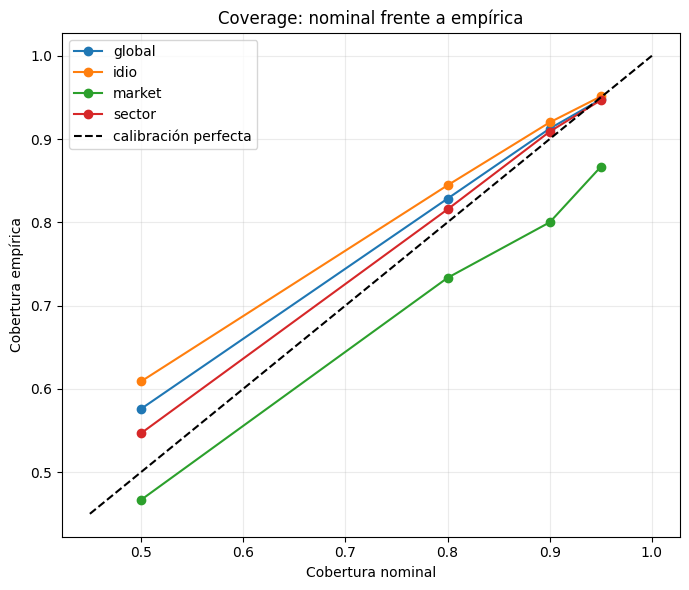

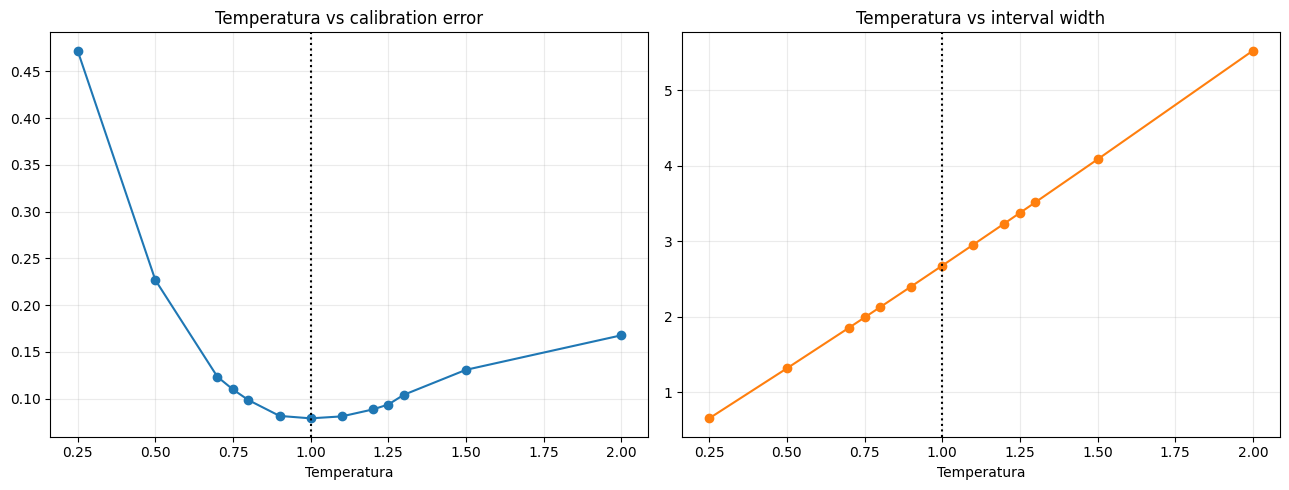

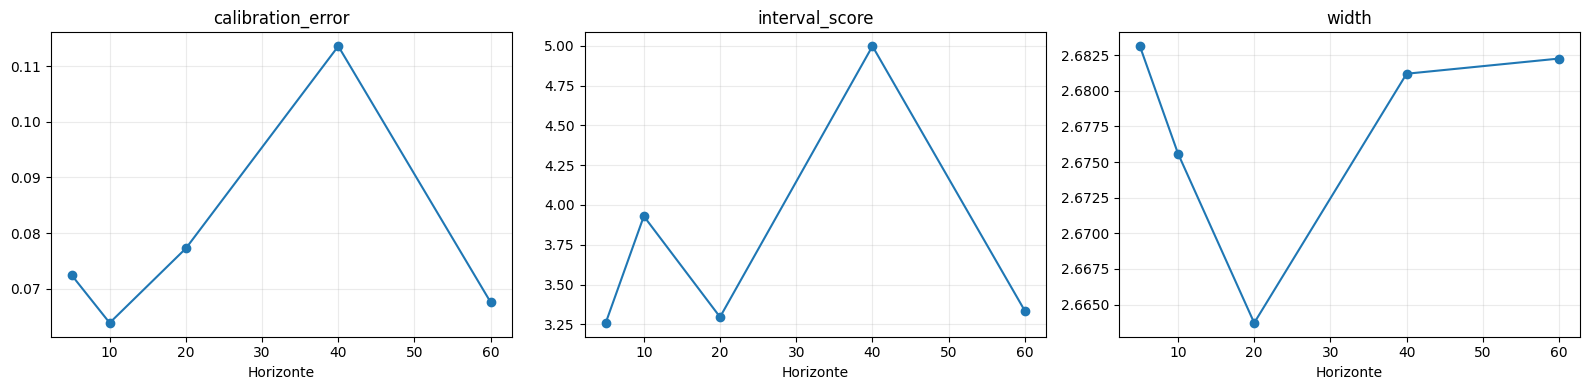

Seleccionado exclusivamente con validation:


,candidate_id,architecture,context_length,temperature,mean_coverage_error,mean_interval_width,mean_interval_score,mean_crps
0,4,gru_128,10,1.0,0.078948,2.677182,3.763137,0.517763


In [40]:
selected_validation = validation_summary_df.iloc[0]
SELECTED_CANDIDATE_ID = int(selected_validation['candidate_id'])
SELECTED_TEMPERATURE = float(selected_validation['temperature'])
selected_row = finalists_df.query('candidate_id == @SELECTED_CANDIDATE_ID').iloc[0]

def save_show(fig, name):
    fig.tight_layout(); fig.savefig(CALIBRATION_FIGURE_DIR/'calibration'/name, dpi=150, bbox_inches='tight')
    plt.show(); plt.close(fig)

selected_metrics = validation_metrics_df.query(
    "candidate_id == @SELECTED_CANDIDATE_ID and temperature == @SELECTED_TEMPERATURE"
)
fig, axis = plt.subplots(figsize=(7, 6))
for family, group in selected_metrics.groupby('family'):
    curve = group.groupby('nominal_coverage')['empirical_coverage'].mean()
    axis.plot(curve.index, curve.values, marker='o', label=family)
axis.plot([0.45, 1], [0.45, 1], 'k--', label='calibración perfecta')
axis.set(xlabel='Cobertura nominal', ylabel='Cobertura empírica', title='Coverage: nominal frente a empírica')
axis.legend(); axis.grid(alpha=.25); save_show(fig, 'coverage_vs_nominal.png')

temperature_plot = validation_metrics_df.query("family == 'global' and candidate_id == @SELECTED_CANDIDATE_ID").groupby('temperature').agg(
    calibration_error=('coverage_error', 'mean'), width=('mean_interval_width', 'mean'),
    interval_score=('mean_interval_score', 'mean')).reset_index()
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(temperature_plot['temperature'], temperature_plot['calibration_error'], marker='o')
axes[0].axvline(SELECTED_TEMPERATURE, color='black', linestyle=':'); axes[0].set_title('Temperatura vs calibration error')
axes[1].plot(temperature_plot['temperature'], temperature_plot['width'], marker='o', color='C1')
axes[1].axvline(SELECTED_TEMPERATURE, color='black', linestyle=':'); axes[1].set_title('Temperatura vs interval width')
for axis in axes: axis.set_xlabel('Temperatura'); axis.grid(alpha=.25)
save_show(fig, 'temperature_calibration_and_width.png')

horizon_plot = selected_metrics.query("family == 'global'").groupby('horizon').agg(
    calibration_error=('coverage_error', 'mean'), interval_score=('mean_interval_score', 'mean'),
    width=('mean_interval_width', 'mean')).reset_index()
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for axis, metric in zip(axes, ('calibration_error', 'interval_score', 'width')):
    axis.plot(horizon_plot['horizon'], horizon_plot[metric], marker='o'); axis.set_title(metric)
    axis.set_xlabel('Horizonte'); axis.grid(alpha=.25)
save_show(fig, 'calibration_by_horizon.png')

print('Seleccionado exclusivamente con validation:')
display(selected_validation.to_frame().T)


## 14. Bandas predictivas frente al futuro observado

No se dibujan las 500 trayectorias. Para componentes representativos se muestran la mediana y las bandas centrales del 50%, 80% y 95%, junto con la única realización futura observada.


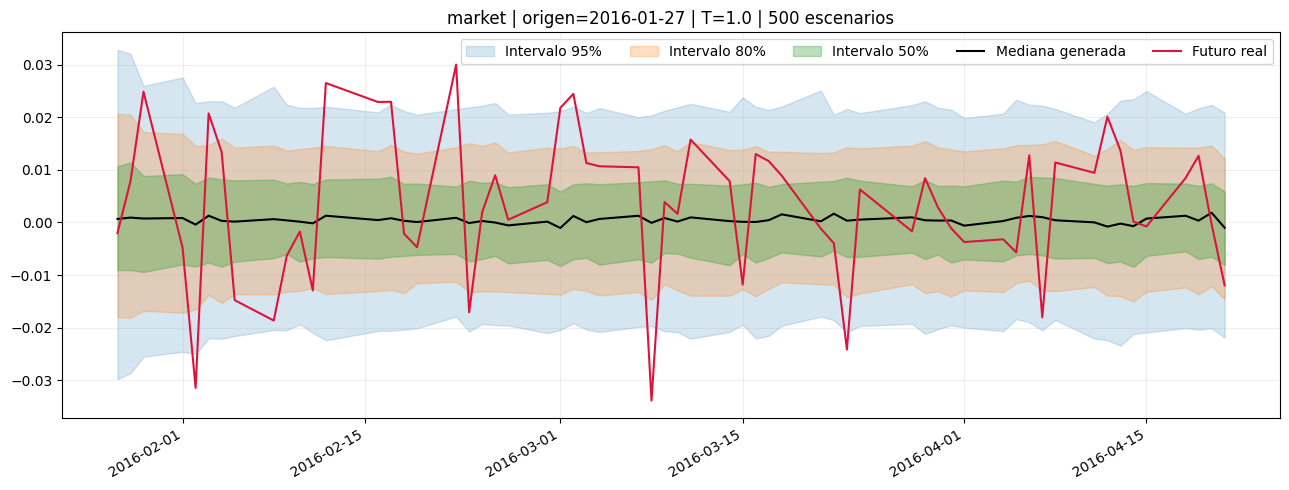

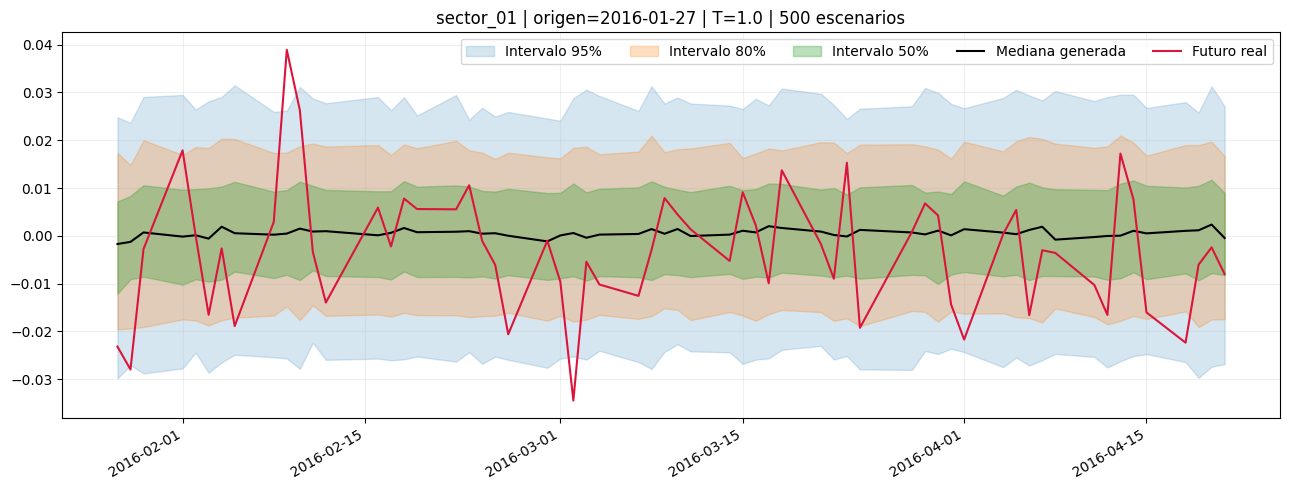

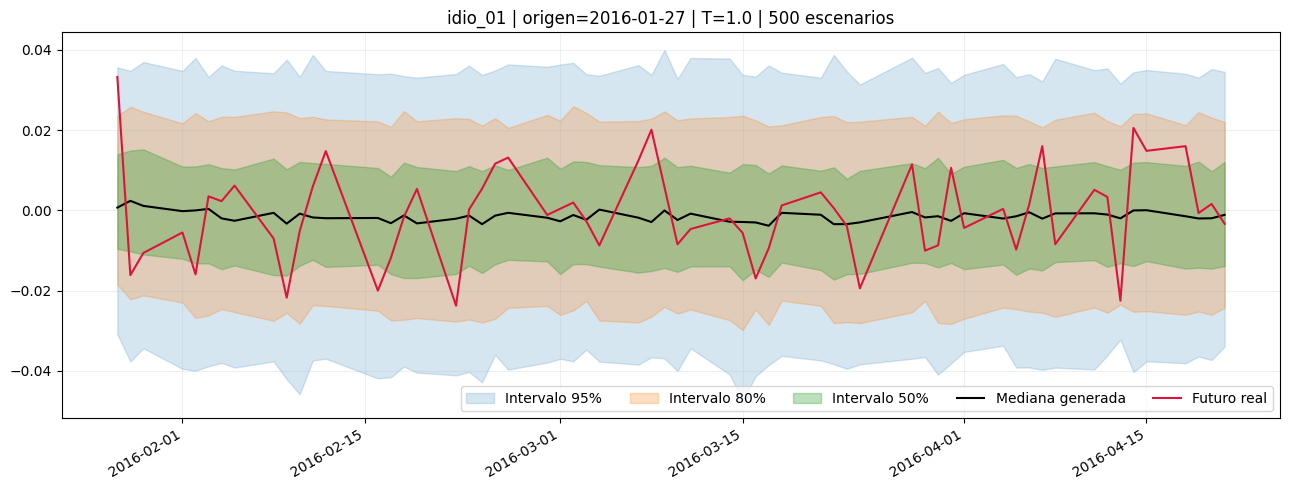

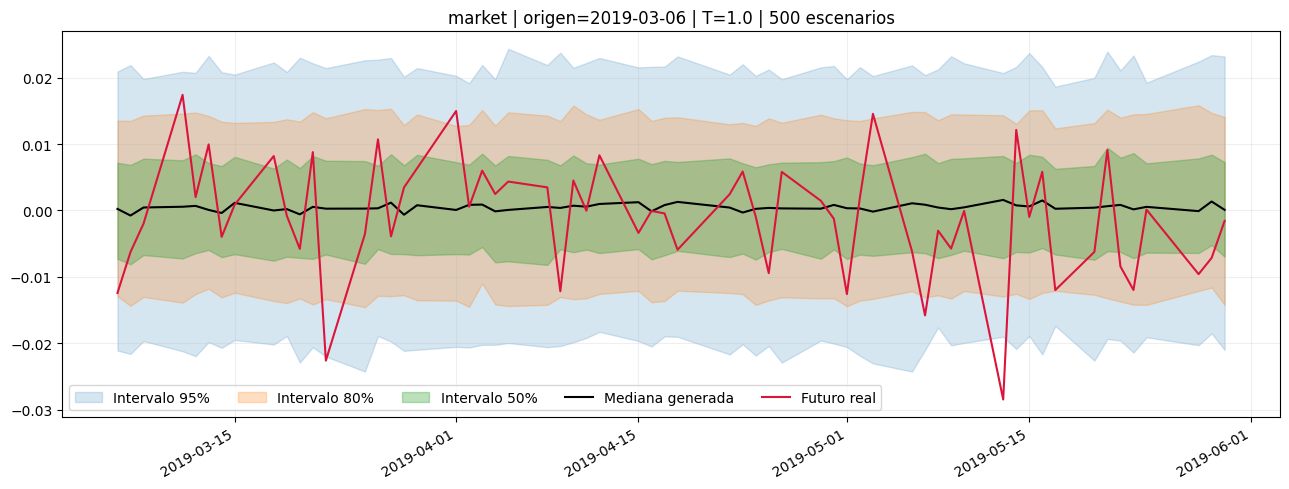

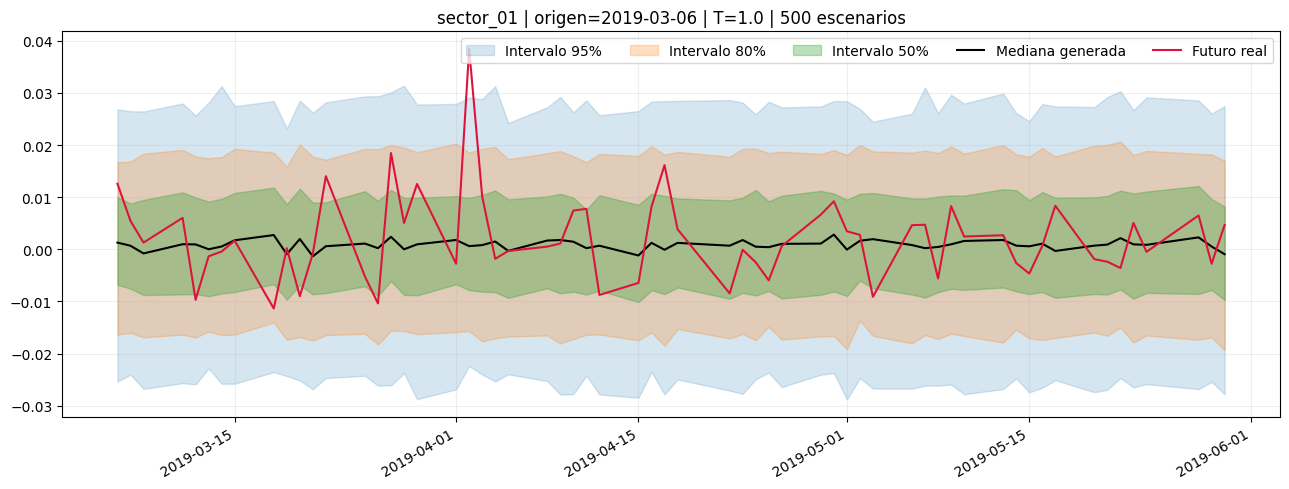

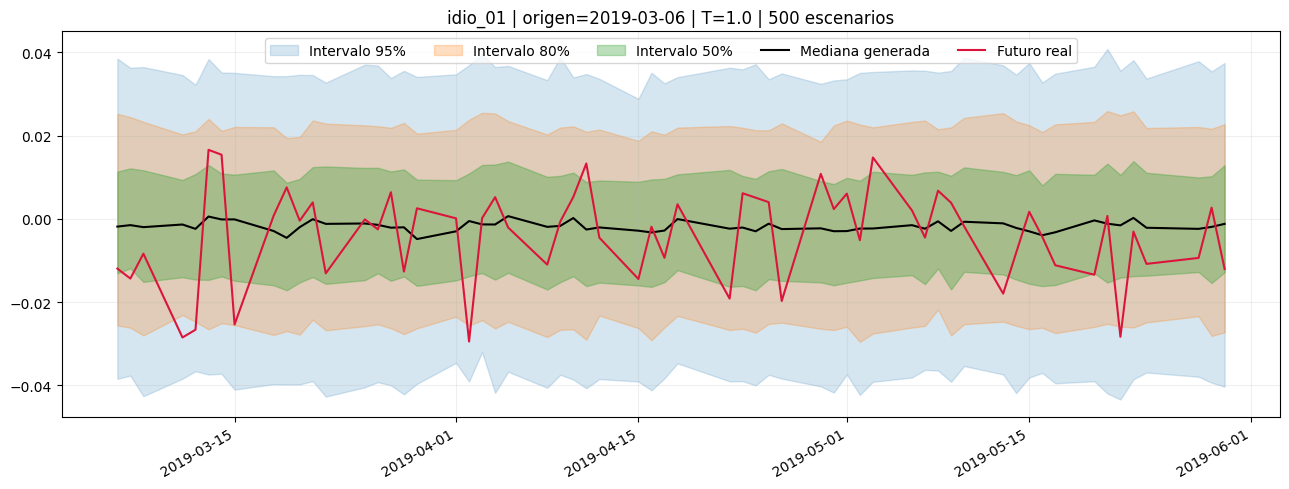

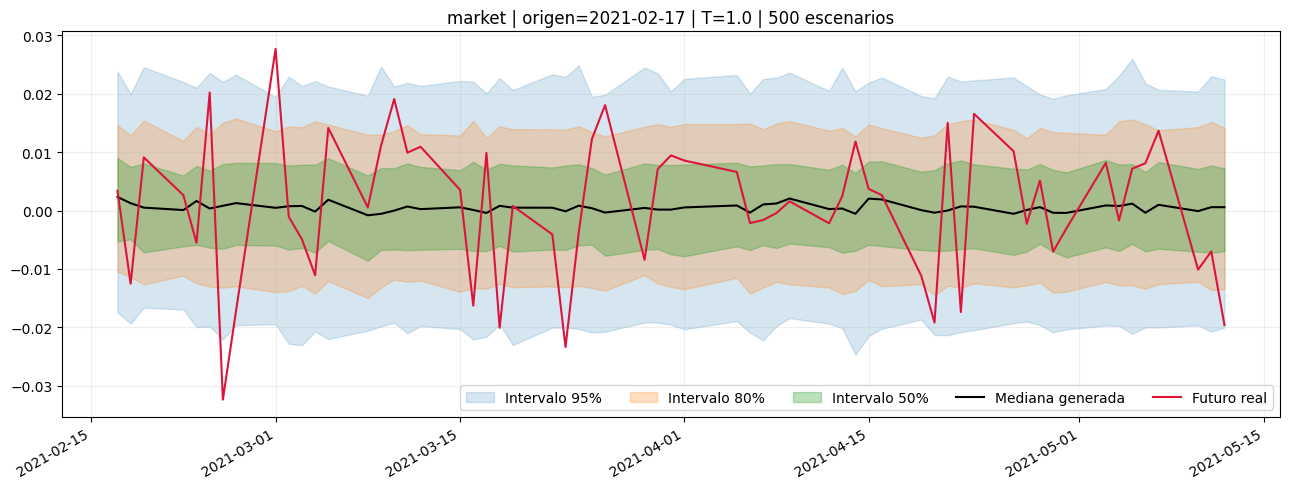

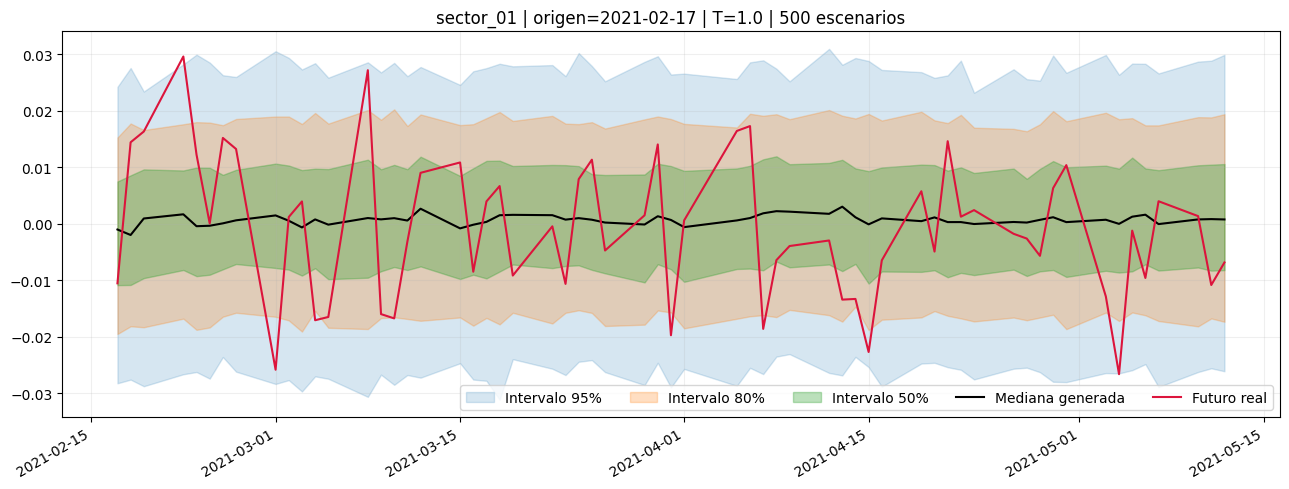

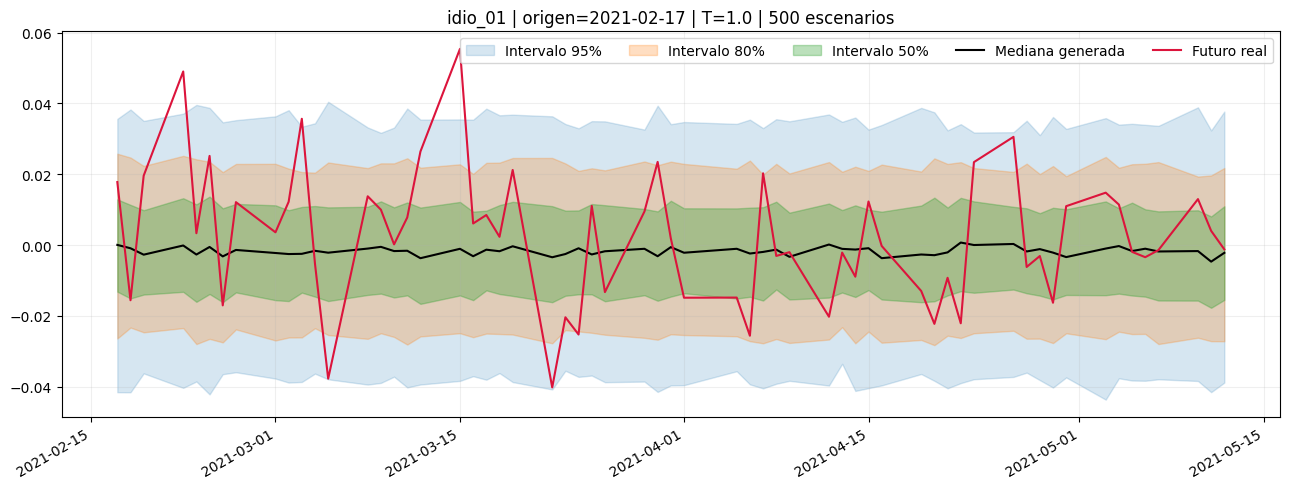

In [41]:
def plot_predictive_bands(origin_id, origin, denormalized_cube, component_id, label):
    scenarios = denormalized_cube[:, :, component_id]
    real = components.iloc[origin:origin+max(HORIZONS), component_id]
    future_dates = components.index[origin:origin+max(HORIZONS)]
    fig, axis = plt.subplots(figsize=(13, 5))
    for level, alpha, color in ((0.95, .18, 'C0'), (0.80, .25, 'C1'), (0.50, .32, 'C2')):
        tail = (1-level)/2
        lower, upper = np.quantile(scenarios, [tail, 1-tail], axis=0)
        axis.fill_between(future_dates, lower, upper, alpha=alpha, color=color, label=f'Intervalo {int(level*100)}%')
    axis.plot(future_dates, np.median(scenarios, axis=0), color='black', label='Mediana generada')
    axis.plot(future_dates, real.to_numpy(), color='crimson', linewidth=1.5, label='Futuro real')
    axis.set_title(
        f'{label} | origen={components.index[origin].date()} | '
        f'T={SELECTED_TEMPERATURE} | {N_SCENARIOS} escenarios'
    )
    axis.legend(ncol=5); axis.grid(alpha=.2); fig.autofmt_xdate()
    fig.tight_layout()
    figure_name = f'origin_{origin_id:02d}_{components.index[origin].date()}_{label}.png'
    fig.savefig(CALIBRATION_FIGURE_DIR/'bands'/figure_name, dpi=150, bbox_inches='tight')
    plt.show(); plt.close(fig)

# Varias fechas representativas: todos los orígenes de calibration (normalmente tres).
for origin_id, origin in enumerate(calibration_origins):
    representative_seed = SEED + 91000 + origin_id
    representative_cube, _, _, representative_scaler = generate_scenario_cube(
        selected_row, int(origin), SELECTED_TEMPERATURE, N_SCENARIOS, representative_seed,
    )
    denormalized_cube = representative_scaler.inverse_transform(
        representative_cube.reshape(-1, representative_cube.shape[-1])
    ).reshape(representative_cube.shape)
    for component_id, label in ((0, 'market'), (1, 'sector_01'), (31, 'idio_01')):
        plot_predictive_bands(origin_id, int(origin), denormalized_cube, component_id, label)


### Lectura de las gráficas de la sección 14

Las bandas obtenidas muestran una limitación importante: los futuros centrales son **demasiado planos**, suavizan en exceso la dinámica y no reproducen bien la trayectoria irregular que realmente ocurrió. A ello se suma lo observado en las curvas de entrenamiento: los modelos anteriores alcanzaban su mejor época muy pronto y después train y validation se separaban con rapidez. Es decir, la red estaba sobreajustando y la generación recursiva basada únicamente en el siguiente día no estaba aprendiendo una dinámica futura suficientemente rica.

La temperatura puede ampliar o reducir la dispersión, pero no puede corregir por sí sola una dinámica central excesivamente plana ni una convergencia deficiente. Por eso, desde este punto se plantea un segundo experimento con un objetivo de entrenamiento diferente.


## 15. Nuevo objetivo: distribución conjunta de los próximos cinco días

El nuevo modelo recibe una ventana histórica y predice simultáneamente los parámetros gaussianos de los cinco días siguientes:

$$p(C_{t+1:t+5}\mid C_{t-L+1:t}).$$

La salida tiene forma `(5, 61)` tanto para $\mu$ como para $\sigma$. La loss utiliza los cinco leads y mantiene exactamente los pesos anteriores:

$$L=0.20L_{market}+0.50L_{sector}+0.30L_{idio}.$$

Para generar 60 días se utiliza un rollout rolling:

1. Se predicen las distribuciones de los próximos cinco días.
2. Se muestrea el primer día y se concatena al contexto.
3. Con el contexto actualizado se vuelven a predecir los siguientes cinco días.
4. Se muestrea el primer día de esta **nueva** distribución y se repite el proceso.

Aunque la red aprende los cinco leads conjuntamente, durante el rollout se usa siempre el primer lead de la predicción actualizada. Usar el segundo lead después de desplazar el contexto saltaría un día de calendario. El aprendizaje a cinco días obliga a la representación interna a explicar dinámica futura más allá del valor inmediato, mientras que cada día generado condiciona todas las predicciones posteriores.


In [ ]:
from src.generators.autoregressive import (
    ProbabilisticMultiHorizonGRU,
    generate_multihorizon_rolling_batch,
    make_multihorizon_samples,
    multihorizon_target_indices,
    split_multihorizon_targets,
)

PREDICTION_HORIZON = 5
MULTI_CONTEXT_LENGTHS = [10, 20, 40, 60]
MULTI_ARCHITECTURES = {
    # Grid deliberadamente pequeño y regularizado por el sobreajuste anterior.
    'gru_16': {'hidden_dims': [16], 'dropout': 0.10},
    'gru_32': {'hidden_dims': [32], 'dropout': 0.20},
    'gru_64': {'hidden_dims': [64], 'dropout': 0.30},
    'gru_64_32': {'hidden_dims': [64, 32], 'dropout': 0.35},
}
MULTI_MAX_EPOCHS = 300
MULTI_PATIENCE = 30
MULTI_LEARNING_RATE = 0.0005
MULTI_WEIGHT_DECAY = 0.001
MULTI_BATCH_SIZE = 128

MULTI_MODEL_DIR = MODEL_DIR / 'multihorizon_5d'
MULTI_FIGURE_DIR = FIGURE_DIR / 'multihorizon_5d'
for directory in (
    MULTI_MODEL_DIR/'checkpoints', MULTI_MODEL_DIR/'histories',
    MULTI_FIGURE_DIR/'training', MULTI_FIGURE_DIR/'examples',
):
    directory.mkdir(parents=True, exist_ok=True)

MULTI_CANDIDATES = [
    {'architecture': architecture, 'context_length': context_length}
    for architecture in MULTI_ARCHITECTURES
    for context_length in MULTI_CONTEXT_LENGTHS
]
print('Nuevos candidatos:', len(MULTI_CANDIDATES))
display(pd.DataFrame(MULTI_CANDIDATES))


## 16. Grid regularizado y entrenamiento probabilístico a cinco días

Se prueban 16 candidatos con capacidades muy inferiores al grid anterior. Se añade `AdamW` con `weight_decay=0.001`, dropout creciente y early stopping. Los splits temporales, la purga, el scaler ajustado sin validation y los pesos por familia se mantienen. Un ejemplo entra en validation únicamente si sus cinco días objetivo están completamente dentro del bloque; ningún contexto o target de train puede atravesar las zonas de embargo.


In [ ]:
def build_multihorizon_model(candidate):
    architecture = MULTI_ARCHITECTURES[candidate['architecture']]
    return ProbabilisticMultiHorizonGRU(
        input_dim=components.shape[1], prediction_horizon=PREDICTION_HORIZON,
        hidden_dims=architecture['hidden_dims'], dropout=architecture['dropout'],
    )

def prepare_multihorizon_data(context_length):
    targets = multihorizon_target_indices(len(components), context_length, PREDICTION_HORIZON)
    train_idx, val_idx = split_multihorizon_targets(
        targets, validation_blocks, context_length, PREDICTION_HORIZON, purge_size=PURGE_SIZE,
    )
    scaler = StandardScaler().fit(components.loc[~validation_mask].to_numpy())
    normalized = pd.DataFrame(
        scaler.transform(components.to_numpy()), index=components.index, columns=feature_names,
    )
    train_x, train_y = make_multihorizon_samples(
        normalized, context_length, PREDICTION_HORIZON, train_idx,
    )
    val_x, val_y = make_multihorizon_samples(
        normalized, context_length, PREDICTION_HORIZON, val_idx,
    )
    return scaler, train_x, train_y, val_x, val_y

multi_results, multi_histories = [], {}
for candidate_id, candidate in enumerate(MULTI_CANDIDATES):
    set_seed(SEED + 1000 + candidate_id)
    scaler, train_x, train_y, val_x, val_y = prepare_multihorizon_data(candidate['context_length'])
    model = build_multihorizon_model(candidate)
    checkpoint = MULTI_MODEL_DIR/'checkpoints'/f'candidate_{candidate_id:03d}.pt'
    history_path = MULTI_MODEL_DIR/'histories'/f'candidate_{candidate_id:03d}.csv'
    scaler_path = MULTI_MODEL_DIR/'checkpoints'/f'candidate_{candidate_id:03d}_scaler.joblib'
    started = time.perf_counter()
    history, best_epoch, best_score = train_probabilistic_gru(
        model, train_x, train_y, val_x, val_y,
        epochs=MULTI_MAX_EPOCHS, batch_size=MULTI_BATCH_SIZE,
        learning_rate=MULTI_LEARNING_RATE, patience=MULTI_PATIENCE,
        seed=SEED + 1000 + candidate_id, device=DEVICE, checkpoint_path=checkpoint,
        loss_weights=LOSS_WEIGHTS, weight_decay=MULTI_WEIGHT_DECAY,
    )
    history_df = pd.DataFrame(history)
    history_df.to_csv(history_path, index=False); joblib.dump(scaler, scaler_path)
    multi_histories[candidate_id] = history_df
    best = history_df.iloc[best_epoch - 1]
    architecture = MULTI_ARCHITECTURES[candidate['architecture']]
    multi_results.append({
        'candidate_id': candidate_id, **candidate, **architecture,
        'prediction_horizon': PREDICTION_HORIZON,
        'n_parameters': sum(parameter.numel() for parameter in model.parameters()),
        'best_epoch': best_epoch, 'val_selection_score': best_score,
        'val_total_nll': float(best['val_total_nll']),
        'val_market_nll': float(best['val_market_nll']),
        'val_sector_nll': float(best['val_sector_nll']),
        'val_idio_nll': float(best['val_idio_nll']),
        'n_train': len(train_x), 'n_validation': len(val_x),
        'training_seconds': time.perf_counter() - started,
        'weight_decay': MULTI_WEIGHT_DECAY,
        'market_weight': LOSS_WEIGHTS['market'], 'sector_weight': LOSS_WEIGHTS['sector'],
        'idio_weight': LOSS_WEIGHTS['idio'],
        'checkpoint': str(checkpoint), 'scaler_path': str(scaler_path),
        'history_path': str(history_path),
    })

multi_results_df = pd.DataFrame(multi_results).sort_values('val_selection_score').reset_index(drop=True)
multi_results_df.to_csv(MULTI_MODEL_DIR/'candidate_results.csv', index=False)
display(multi_results_df)


## 17. Curvas completas de train y validation

Para todos los candidatos se muestran y guardan las pérdidas sin ponderar de mercado, sector e idiosincrático, la loss ponderada oficial, la NLL total sin ponderar y la contribución ponderada de cada familia. La línea vertical marca la época restaurada por early stopping.


In [ ]:
factor_labels = {'market': 'Mercado', 'sector': 'Sector', 'idio': 'Idiosincrático'}

for rank, row in multi_results_df.iterrows():
    candidate_id = int(row['candidate_id'])
    history = multi_histories.get(candidate_id)
    if history is None:
        history = pd.read_csv(row['history_path'])
    fig, axes = plt.subplots(2, 3, figsize=(17, 9), sharex=True)
    for axis, factor in zip(axes[0], ('market', 'sector', 'idio')):
        axis.plot(history['epoch'], history[f'train_{factor}_nll'], label='train')
        axis.plot(history['epoch'], history[f'val_{factor}_nll'], label='validation')
        axis.set_title(f'NLL {factor_labels[factor]} (5 días, sin ponderar)')
        axis.set_ylabel('NLL'); axis.grid(alpha=.25); axis.legend()
    axes[1, 0].plot(history['epoch'], history['train_selection_score'], label='train')
    axes[1, 0].plot(history['epoch'], history['val_selection_score'], label='validation')
    axes[1, 0].axvline(row['best_epoch'], color='black', linestyle=':', label='best epoch')
    axes[1, 0].set_title('Loss ponderada 0.20 / 0.50 / 0.30'); axes[1, 0].legend(); axes[1, 0].grid(alpha=.25)
    axes[1, 1].plot(history['epoch'], history['train_total_nll'], label='train')
    axes[1, 1].plot(history['epoch'], history['val_total_nll'], label='validation')
    axes[1, 1].axvline(row['best_epoch'], color='black', linestyle=':', label='best epoch')
    axes[1, 1].set_title('NLL total sin ponderar'); axes[1, 1].legend(); axes[1, 1].grid(alpha=.25)
    for factor, color in zip(('market', 'sector', 'idio'), ('C0', 'C1', 'C2')):
        axes[1, 2].plot(
            history['epoch'], LOSS_WEIGHTS[factor] * history[f'val_{factor}_nll'],
            color=color, label=f"{factor_labels[factor]} × {LOSS_WEIGHTS[factor]:.2f}",
        )
    axes[1, 2].plot(history['epoch'], history['val_selection_score'], color='black', linewidth=2, label='Suma')
    axes[1, 2].set_title('Contribuciones ponderadas de validation'); axes[1, 2].legend(); axes[1, 2].grid(alpha=.25)
    for axis in axes[1]: axis.set_xlabel('Epoch')
    fig.suptitle(
        f"Rank {rank+1} | {row['architecture']} | context={row['context_length']} | "
        f"params={int(row['n_parameters']):,} | best_epoch={int(row['best_epoch'])}", fontsize=13,
    )
    fig.tight_layout()
    fig.savefig(MULTI_FIGURE_DIR/'training'/f'rank_{rank+1:02d}_candidate_{candidate_id:03d}.png', dpi=150, bbox_inches='tight')
    plt.show(); plt.close(fig)


## 18. Temperatura y ejemplos de rollouts de 60 días

Se toma el mejor candidato por validation y se fija manualmente `EXAMPLE_TEMPERATURE`. Desde varios pasados diferentes se generan varios caminos para **el mismo activo**. Cada figura muestra un año de historia real, una línea vertical en el origen, el futuro real y los futuros simulados. Se representan retornos acumulados para que la continuidad y la forma de cada camino sean legibles.

Esta sección es únicamente una visualización inicial del nuevo planteamiento. El notebook se detiene aquí: todavía no se realiza una nueva selección por calibración ni otras arquitecturas.


In [ ]:
EXAMPLE_TEMPERATURE = 1.00  # Cambiar manualmente para comparar dispersión.
N_EXAMPLE_PATHS = 8
EXAMPLE_GENERATION_HORIZON = 60
HISTORY_DAYS = 252
EXAMPLE_ASSET = returns_real.columns[0]
N_EXAMPLE_ORIGINS = 3

best_multi_row = multi_results_df.iloc[0]
best_multi_candidate = {
    'architecture': best_multi_row['architecture'],
    'context_length': int(best_multi_row['context_length']),
}
best_multi_model = build_multihorizon_model(best_multi_candidate).to(DEVICE)
payload = torch.load(best_multi_row['checkpoint'], map_location=DEVICE, weights_only=False)
best_multi_model.load_state_dict(payload['model_state_dict']); best_multi_model.eval()
best_multi_scaler = joblib.load(best_multi_row['scaler_path'])

possible_origins = [
    start for start, end in validation_blocks
    if start >= HISTORY_DAYS and end - start + 1 >= EXAMPLE_GENERATION_HORIZON
]
example_origins = possible_origins[:N_EXAMPLE_ORIGINS]
asset_position = returns_real.columns.get_loc(EXAMPLE_ASSET)

for example_id, origin in enumerate(example_origins):
    context_length = best_multi_candidate['context_length']
    context = components.iloc[origin-context_length:origin]
    normalized_context = best_multi_scaler.transform(context.to_numpy()).astype(np.float32)
    generated, _, _ = generate_multihorizon_rolling_batch(
        best_multi_model, normalized_context, EXAMPLE_GENERATION_HORIZON,
        temperature=EXAMPLE_TEMPERATURE, n_paths=N_EXAMPLE_PATHS,
        seed=SEED + 120000 + example_id, device=DEVICE,
    )
    denormalized = best_multi_scaler.inverse_transform(
        generated.reshape(-1, generated.shape[-1])
    ).reshape(generated.shape)
    future_dates = components.index[origin:origin+EXAMPLE_GENERATION_HORIZON]
    generated_asset_returns = []
    for path_values in denormalized:
        factor_frame = pd.DataFrame(path_values, index=future_dates, columns=feature_names)
        generated_asset_returns.append(factors_to_returns(factor_frame).iloc[:, asset_position].to_numpy())
    generated_asset_returns = np.asarray(generated_asset_returns)

    past = returns_real[EXAMPLE_ASSET].iloc[origin-HISTORY_DAYS:origin]
    real_future = returns_real[EXAMPLE_ASSET].iloc[origin:origin+EXAMPLE_GENERATION_HORIZON]
    past_curve = (1 + past).cumprod()
    anchor = float(past_curve.iloc[-1])
    real_curve = anchor * (1 + real_future).cumprod()
    generated_curves = anchor * np.cumprod(1 + generated_asset_returns, axis=1)

    fig, axis = plt.subplots(figsize=(15, 6))
    axis.plot(past.index, past_curve, color='steelblue', linewidth=1.5, label='Pasado real (1 año)')
    axis.plot(real_future.index, real_curve, color='black', linewidth=2.5, label='Futuro real')
    for path_id, curve in enumerate(generated_curves):
        axis.plot(future_dates, curve, color='C1', alpha=.38, linewidth=1,
                  label='Futuros generados' if path_id == 0 else None)
    axis.axvline(components.index[origin], color='crimson', linestyle='--', label='Inicio generación')
    axis.set_title(
        f'{EXAMPLE_ASSET} | modelo 5 días rolling | T={EXAMPLE_TEMPERATURE} | '
        f'{N_EXAMPLE_PATHS} caminos | origen={components.index[origin].date()}'
    )
    axis.set_ylabel('Crecimiento acumulado de 1 unidad'); axis.legend(); axis.grid(alpha=.2)
    fig.tight_layout()
    fig.savefig(
        MULTI_FIGURE_DIR/'examples'/f'origin_{example_id:02d}_{EXAMPLE_ASSET}_temperature_{EXAMPLE_TEMPERATURE:.2f}.png',
        dpi=150, bbox_inches='tight',
    )
    plt.show(); plt.close(fig)

print('Mejor nuevo modelo:', best_multi_candidate)
print('Temperatura visualizada:', EXAMPLE_TEMPERATURE)
